# 0. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import string
from sklearn.model_selection import train_test_split
import random
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from rnn_modules import *

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

In [ ]:
# generator для Даталоудера
g = torch.Generator()
g.manual_seed(21)

# 1. Give the answer to the question from the introduction

Во введении фигурировало несколько вопросов:

### 1. Недостатки подхода Encoder–Decoder без механизма внимания

- Потеря информации для длинных последовательностей - последнее скрытое состояние несет в основном информацию о конце предложения, теряя важные детали из начала;
- Декодер на каждом шаге генерации использует один и тот же фиксированный вектор - не позволяет учитывать "важность" слов и важность связи между словами;
- Затухающие градиенты - даже если использовать LSTM или GRU, градиенты, передаваемые от декодера к энкодеру через последнее состояние, могут затухать или взрываться.

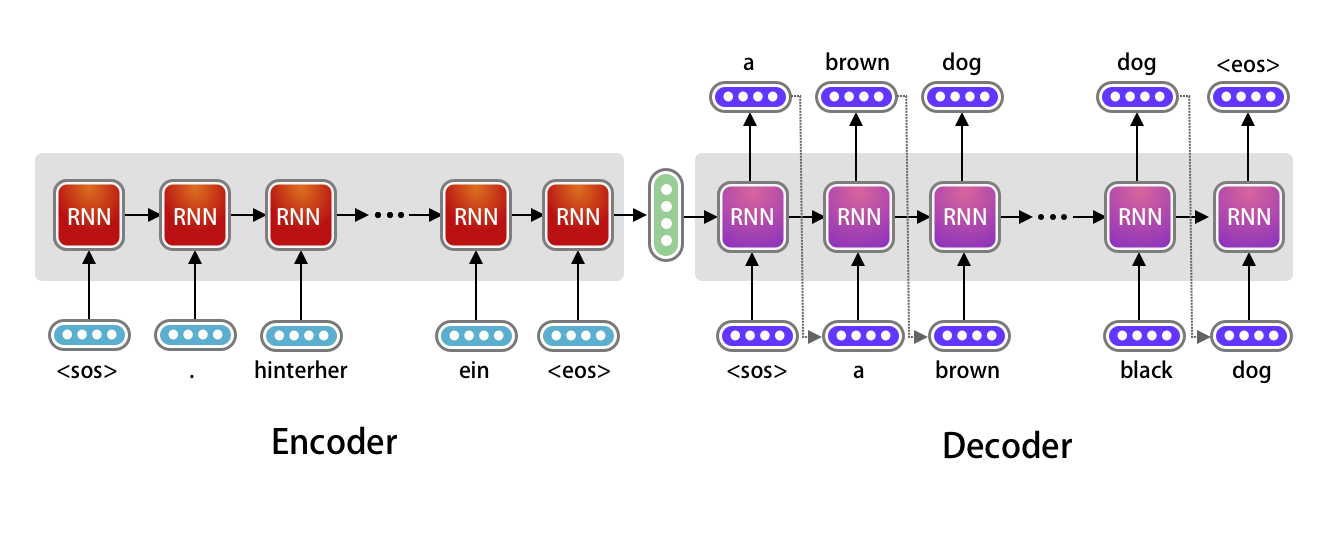

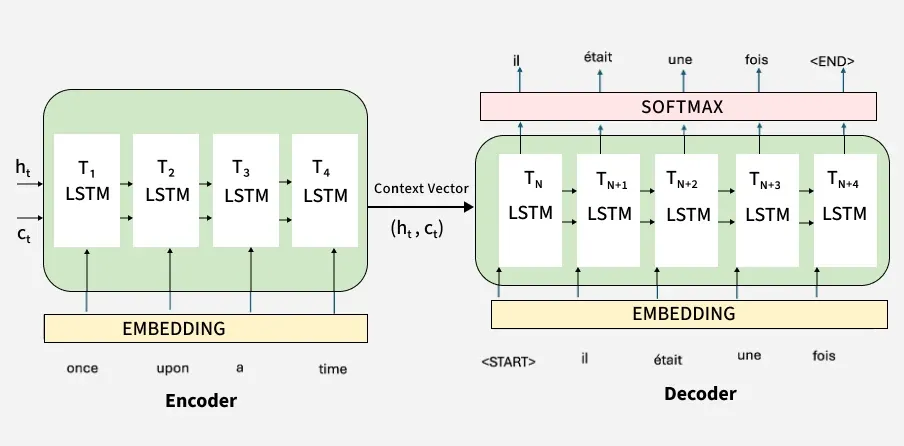

### 2. Как работает механизм внимания для подхода Encoder–Decoder

- Для каждого слова в исходном предложении (энкодер) вычисляются два вектора:

**Key (K)** - вектор, используемый для сравнения с запросом. Он служит идентификатором позиции/содержания слова при оценке сходства.

**Value (V)** -  вектор, представляющий фактическое содержание слова. Он будет участвовать в взвешенном суммировании для формирования выходного представления.

- Для каждого слова в переводе (декодер, текущий шаг генерации) вычисляется вектор:

**Query (Q)** - вектор запроса, который сопоставляется со всеми ключами (Keys) исходного предложения для определения весов внимания.

- Как считается внимание
1) Берётся Query текущего слова перевода и Keys всех слов исходного предложения.
2) Для каждой пары вычисляется скалярное произведение (dot product). Чем оно больше, тем сильнее запрос похож на ключ > тем более связаны эти слова.
3) Все эти числа (сходства) пропускаются через softmax, чтобы получились вероятности (сумма = 1). Они показывают, насколько каждое исходное слово влияет на текущее слово перевода. Полученными вероятностями взвешиваются Value исходных слов.
4) Результат(взвешенная сумма значений) - и есть новое представление текущего слова перевода, которое учитывает весь исходный контекст, но с фокусом на нужные слова.

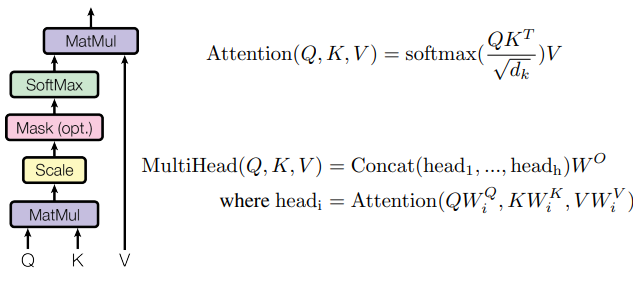

### 3. Как работает позиционный энкодинг

- Механизм внимания является перестановочно-инвариантным: он не учитывает порядок слов во входной последовательности. Позиционное кодирование (Positional Encoding) -  это способ внедрить в модель информацию о порядке, добавив к векторному представлению каждого токена уникальный сигнал, зависящий от его позиции в последовательности.
- В оригинальной статье (Attention Is All You Need) рассматриваются два основных подхода к позиционному кодированию: синусоидальное (не обучаемое) и обучаемое (через nn.Embedding)

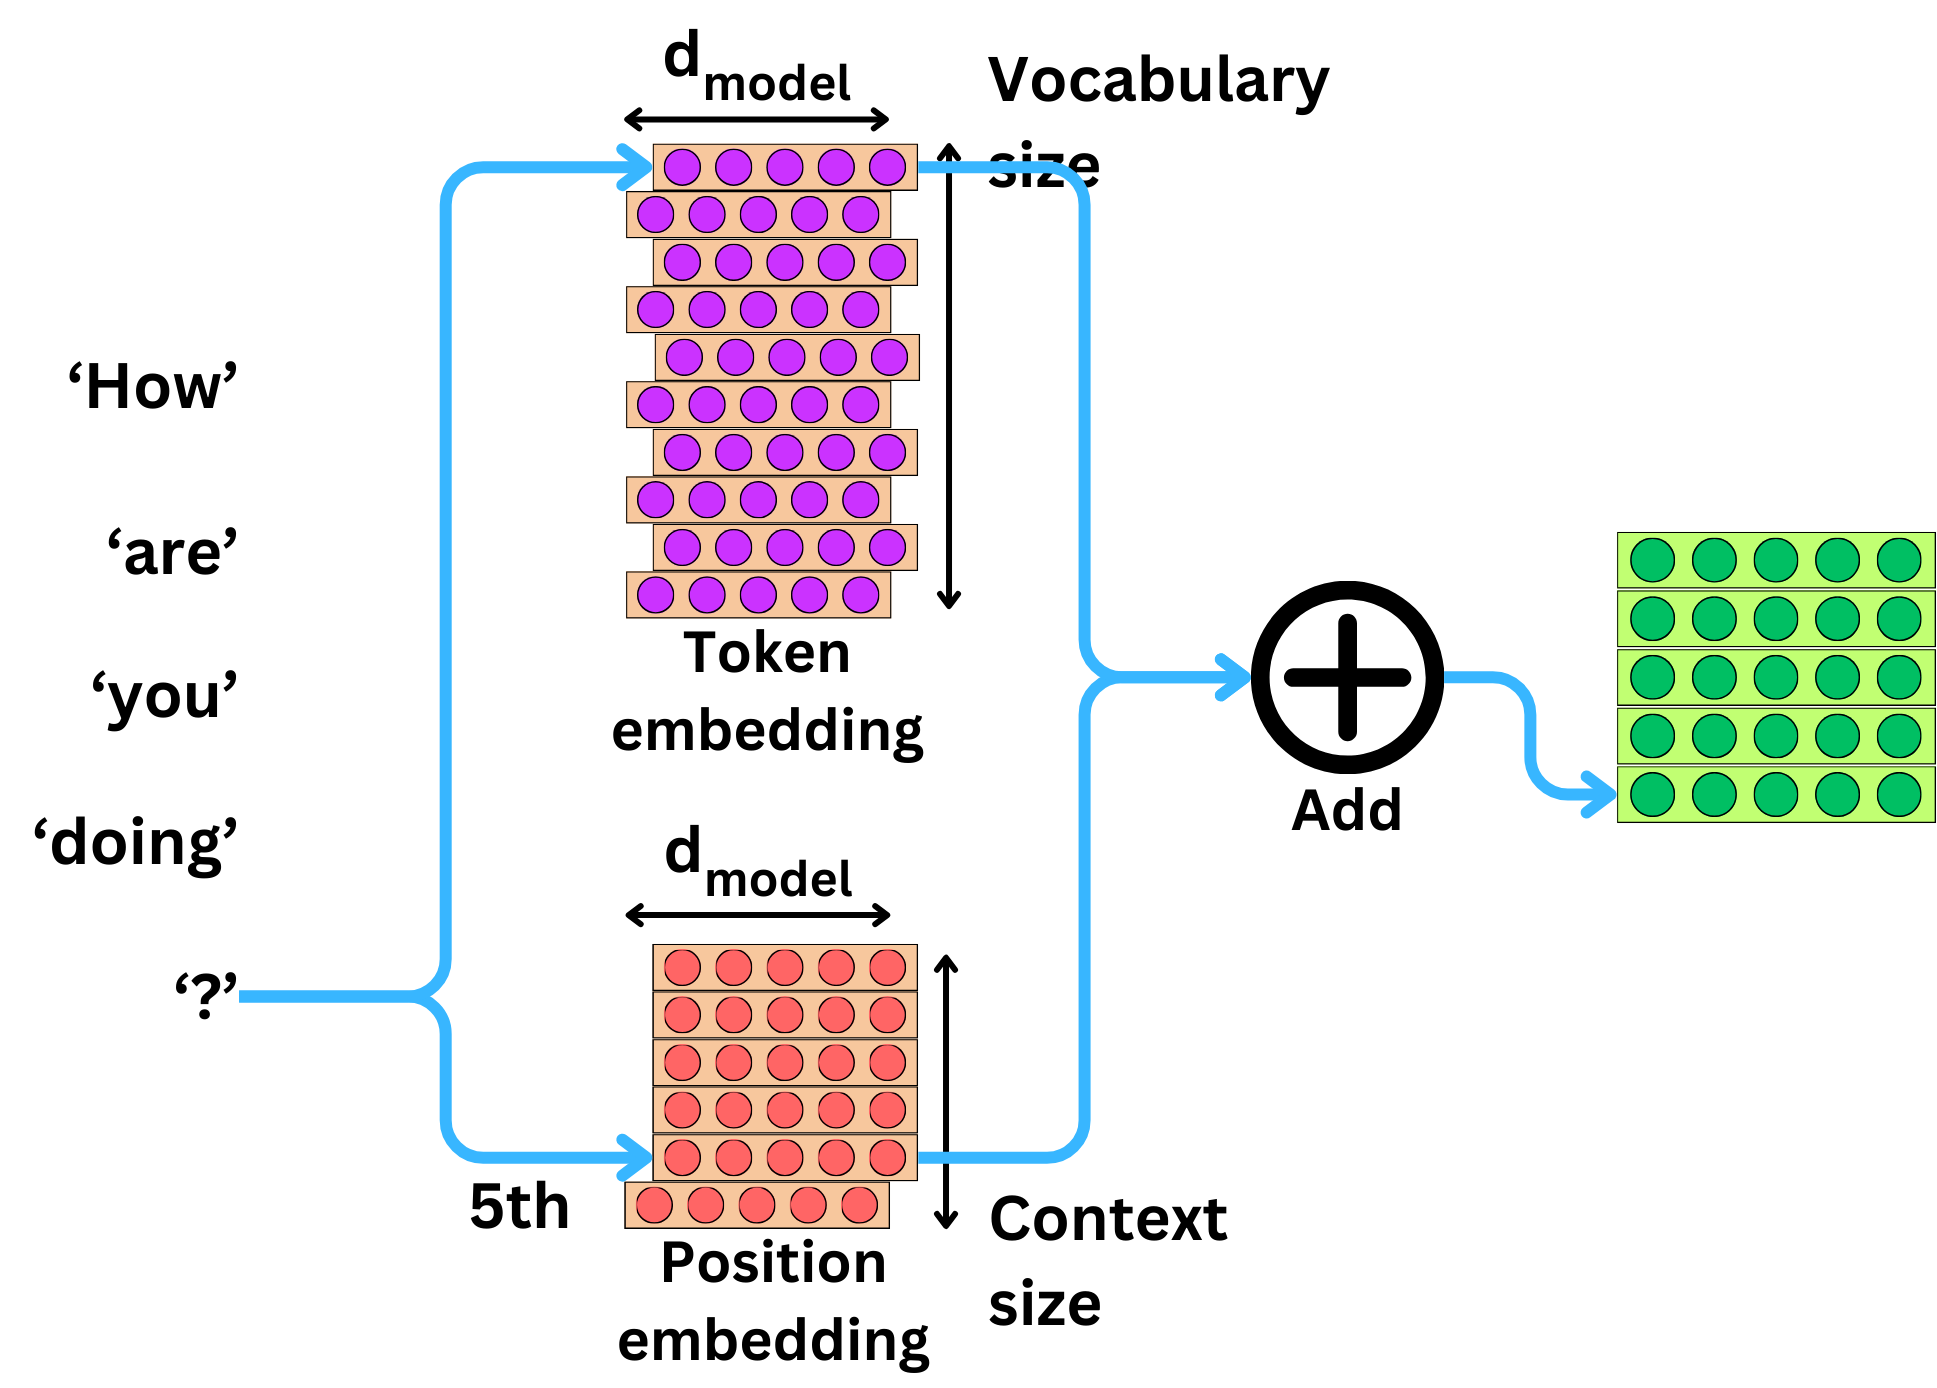

# 2. Data preparation

- a. Download the dataset from the course files.

In [ ]:
!gdown 1VBMRAP7Y-kYkbI_QVQxTNxVY5crWbicA

Downloading...
From: https://drive.google.com/uc?id=1VBMRAP7Y-kYkbI_QVQxTNxVY5crWbicA
To: /content/Names.csv
100% 130k/130k [00:00<00:00, 74.1MB/s]


In [ ]:
name_data = pd.read_csv("/content/Names.csv")
name_data

,English,Russian
0,John,Джон
1,William,Уильям
2,James,Джеймс
3,Charles,Чарльз
4,George,Джордж
...,...,...
6781,Laylah,Лейла
6782,Carleigh,Карли
6783,Kenley,Кенли
6784,Sloane,Слоан


- b. Create 2 dictionaries for English letters and Russian letters. Do not forget special tokens.

In [ ]:
import string
eng_dict = {char: index for index, char in enumerate(string.ascii_lowercase, 1)}
eng_dict["<SOS>"] = 27
eng_dict["<EOS>"] = 28
eng_dict[" "] = 0
eng_dict = dict(sorted(eng_dict.items(), key=lambda item: item[1]))
#eng_dict

In [ ]:
# https://stackoverflow.com/a/76818613
rus_list = [chr(i) for i in range(1072, 1104)]
rus_list = rus_list[0:6] + [chr(1105)] + rus_list[6:] # чтоб добавить ё
print(rus_list)

['а', 'б', 'в', 'г', 'д', 'е', 'ё', 'ж', 'з', 'и', 'й', 'к', 'л', 'м', 'н', 'о', 'п', 'р', 'с', 'т', 'у', 'ф', 'х', 'ц', 'ч', 'ш', 'щ', 'ъ', 'ы', 'ь', 'э', 'ю', 'я']


In [ ]:
rus_dict = {char:index for index, char in enumerate(rus_list, 1)}
rus_dict["<SOS>"] = 34
rus_dict["<EOS>"] = 35
rus_dict[" "] = 0
rus_dict = dict(sorted(rus_dict.items(), key=lambda item: item[1]))
#rus_dict

- c. Encode names.

In [ ]:
name_data['eng_tokens'] = name_data['English'].apply(lambda s: ["<SOS>"] + list(s.lower()) + ["<EOS>"])
name_data['rus_tokens'] = name_data['Russian'].apply(lambda s: ["<SOS>"] + list(s.lower()) + ["<EOS>"])

# паддинг
eng_max_len = name_data['eng_tokens'].str.len().max()
rus_max_len = name_data['rus_tokens'].str.len().max()

name_data['eng_tokens_padded'] = name_data['eng_tokens'].apply(lambda s: s + [' ']* (eng_max_len - len(s)))
name_data['rus_tokens_padded'] = name_data['rus_tokens'].apply(lambda s: s + [' ']* (rus_max_len - len(s)))
name_data

,English,Russian,eng_tokens,rus_tokens,eng_tokens_padded,rus_tokens_padded
0,John,Джон,"[<SOS>, j, o, h, n, <EOS>]","[<SOS>, д, ж, о, н, <EOS>]","[<SOS>, j, o, h, n, <EOS>, , , , , , , ]","[<SOS>, д, ж, о, н, <EOS>, , , , , , , ..."
1,William,Уильям,"[<SOS>, w, i, l, l, i, a, m, <EOS>]","[<SOS>, у, и, л, ь, я, м, <EOS>]","[<SOS>, w, i, l, l, i, a, m, <EOS>, , , , ]","[<SOS>, у, и, л, ь, я, м, <EOS>, , , , , ..."
2,James,Джеймс,"[<SOS>, j, a, m, e, s, <EOS>]","[<SOS>, д, ж, е, й, м, с, <EOS>]","[<SOS>, j, a, m, e, s, <EOS>, , , , , , ]","[<SOS>, д, ж, е, й, м, с, <EOS>, , , , , ..."
3,Charles,Чарльз,"[<SOS>, c, h, a, r, l, e, s, <EOS>]","[<SOS>, ч, а, р, л, ь, з, <EOS>]","[<SOS>, c, h, a, r, l, e, s, <EOS>, , , , ]","[<SOS>, ч, а, р, л, ь, з, <EOS>, , , , , ..."
4,George,Джордж,"[<SOS>, g, e, o, r, g, e, <EOS>]","[<SOS>, д, ж, о, р, д, ж, <EOS>]","[<SOS>, g, e, o, r, g, e, <EOS>, , , , , ]","[<SOS>, д, ж, о, р, д, ж, <EOS>, , , , , ..."
...,...,...,...,...,...,...
6781,Laylah,Лейла,"[<SOS>, l, a, y, l, a, h, <EOS>]","[<SOS>, л, е, й, л, а, <EOS>]","[<SOS>, l, a, y, l, a, h, <EOS>, , , , , ]","[<SOS>, л, е, й, л, а, <EOS>, , , , , , ..."
6782,Carleigh,Карли,"[<SOS>, c, a, r, l, e, i, g, h, <EOS>]","[<SOS>, к, а, р, л, и, <EOS>]","[<SOS>, c, a, r, l, e, i, g, h, <EOS>, , , ]","[<SOS>, к, а, р, л, и, <EOS>, , , , , , ..."
6783,Kenley,Кенли,"[<SOS>, k, e, n, l, e, y, <EOS>]","[<SOS>, к, е, н, л, и, <EOS>]","[<SOS>, k, e, n, l, e, y, <EOS>, , , , , ]","[<SOS>, к, е, н, л, и, <EOS>, , , , , , ..."
6784,Sloane,Слоан,"[<SOS>, s, l, o, a, n, e, <EOS>]","[<SOS>, с, л, о, а, н, <EOS>]","[<SOS>, s, l, o, a, n, e, <EOS>, , , , , ]","[<SOS>, с, л, о, а, н, <EOS>, , , , , , ..."


In [ ]:
name_data['eng_name_to_id'] = name_data['eng_tokens_padded'].apply(lambda s:[eng_dict[ch] for ch in s])
name_data['rus_name_to_id'] = name_data['rus_tokens_padded'].apply(lambda s: [rus_dict[ch] for ch in s])
name_data.sample(1)

,English,Russian,eng_tokens,rus_tokens,eng_tokens_padded,rus_tokens_padded,eng_name_to_id,rus_name_to_id
860,Gustaf,Густав,"[<SOS>, g, u, s, t, a, f, <EOS>]","[<SOS>, г, у, с, т, а, в, <EOS>]","[<SOS>, g, u, s, t, a, f, <EOS>, , , , , ]","[<SOS>, г, у, с, т, а, в, <EOS>, , , , , ...","[27, 7, 21, 19, 20, 1, 6, 28, 0, 0, 0, 0, 0]","[34, 4, 21, 19, 20, 1, 3, 35, 0, 0, 0, 0, 0, 0]"


- d. Divide the dataset into training, valid and test parts (take 80-10-10%). Be sure to use random_state.

In [ ]:
train_data, testval_data = train_test_split(name_data[['English','eng_name_to_id','rus_name_to_id']], test_size = 0.2, random_state=21)
valid_data, test_data = train_test_split(testval_data, test_size = 0.5, random_state=21)

In [ ]:
# проверяем размеры
print(train_data.shape)
print(valid_data.shape)
print(test_data.shape)
test_data.head()

(5428, 3)
(679, 3)
(679, 3)


,English,eng_name_to_id,rus_name_to_id
642,Avery,"[27, 1, 22, 5, 18, 25, 28, 0, 0, 0, 0, 0, 0]","[34, 31, 3, 6, 18, 10, 35, 0, 0, 0, 0, 0, 0, 0]"
6527,Aiyana,"[27, 1, 9, 25, 1, 14, 1, 28, 0, 0, 0, 0, 0]","[34, 1, 11, 33, 15, 1, 35, 0, 0, 0, 0, 0, 0, 0]"
3762,Sina,"[27, 19, 9, 14, 1, 28, 0, 0, 0, 0, 0, 0, 0]","[34, 19, 10, 15, 1, 35, 0, 0, 0, 0, 0, 0, 0, 0]"
6286,Eryn,"[27, 5, 18, 25, 14, 28, 0, 0, 0, 0, 0, 0, 0]","[34, 31, 18, 10, 15, 35, 0, 0, 0, 0, 0, 0, 0, 0]"
2814,Samir,"[27, 19, 1, 13, 9, 18, 28, 0, 0, 0, 0, 0, 0]","[34, 19, 1, 14, 10, 18, 35, 0, 0, 0, 0, 0, 0, 0]"


# 3. RNN Encoder

- a. Train a 1-layer RNN model (GRU or LSTM) to encode the English name. Use built-in class of Neural Network Library.

In [ ]:
class RNN_Encoder(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_size):
    super().__init__()
    self.emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
    self.rnn = nn.GRU(embed_dim, hidden_size, batch_first=True)
    self.next_token_fc = nn.Linear(hidden_size, vocab_size)

  def forward(self, x, hidden=None):
    emb = self.emb(x) # emb: ((B, S), E)
    output, last_hidden = self.rnn(emb, hidden) # output: (B, S, HS), last_hid: (1, B, HS)
    output = self.next_token_fc(output) # output: (B, S, VS)
    return output

In [ ]:
class NameDataset(Dataset):
  def __init__(self, eng_seqs):
    self.eng_seqs = torch.tensor(eng_seqs, dtype=torch.long)

  def __len__(self):
    return len(self.eng_seqs)

  def __getitem__(self, idx):
    return self.eng_seqs[idx]

In [ ]:
def create_datasets(train, valid, test):
  X_train = np.array(train["eng_name_to_id"].tolist())
  X_valid = np.array(valid["eng_name_to_id"].tolist())
  X_test = np.array(test["eng_name_to_id"].tolist())

  train_dataset = NameDataset(X_train)
  valid_dataset = NameDataset(X_valid)
  test_dataset = NameDataset(X_test)

  return train_dataset, valid_dataset, test_dataset

- b. Add early stopping by validation metric to training procedure.

In [ ]:
def train_encoder(model, train_loader, valid_loader, criterion, optimizer, num_epochs, scheduler=None, patience=5):
  train_losses, val_losses = [], []
  device = "cuda" if torch.cuda.is_available() else 'cpu'
  model = model.to(device)

  best_val_loss = float('inf')
  patience_counter = 0

  for epoch in range(num_epochs):
    model.train()

    # будем усреднять лосс по батчам
    total_train_loss = 0.0
    num_batches_train = 0

    for batch_seq in train_loader:
      batch_seq = batch_seq.to(device)
      optimizer.zero_grad()

      letter_logits = model(batch_seq) # (B, S, VS)
      output_letter = letter_logits[:, :-1, :].reshape(-1, letter_logits.size(-1))  # (B, S - 1, VS)
      target_letter = batch_seq[:, 1:].reshape(-1) #  (B, S - 1)
      loss = criterion(output_letter, target_letter)
      loss.backward()
      #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step()

      total_train_loss += loss.item()
      num_batches_train += 1

    avg_train_loss = total_train_loss / num_batches_train
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0.0
    num_batches_val = 0

    with torch.no_grad():
      for batch_seq in valid_loader:
        batch_seq = batch_seq.to(device)
        letter_logits = model(batch_seq)
        output_letter = letter_logits[:, :-1, :].reshape(-1, letter_logits.size(-1))
        target_letter = batch_seq[:, 1:].reshape(-1)
        loss = criterion(output_letter, target_letter)

        total_val_loss += loss.item()
        num_batches_val += 1

      avg_val_loss = total_val_loss / num_batches_val
      val_losses.append(avg_val_loss)

      if scheduler is not None:
        scheduler.step(avg_val_loss)

      print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

    # early stopping
    if avg_val_loss < best_val_loss:
      best_val_loss = avg_val_loss
      patience_counter = 0
      # torch.save(model.state_dict(), 'best_model.pth')
    else:
      patience_counter += 1
      print(f'Validation loss did not improve. Patience: {patience_counter}/{patience}')

    if patience_counter >= patience:
      print(f'Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss for {patience} consecutive epochs.')
      break

  plt.figure(figsize=(10,5))
  plt.plot(train_losses, label='Train Loss')
  plt.plot(val_losses, label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Loss convergence')
  plt.legend()
  plt.grid(True)
  plt.show()

  return train_losses, val_losses

In [ ]:
train_dataset, valid_dataset, test_dataset = create_datasets(train_data, valid_data, test_data)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, generator=g)
val_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Epoch 1/20 | Train Loss: 1.7645 | Val Loss: 1.4243
Epoch 2/20 | Train Loss: 1.3508 | Val Loss: 1.3145
Epoch 3/20 | Train Loss: 1.2779 | Val Loss: 1.2704
Epoch 4/20 | Train Loss: 1.2404 | Val Loss: 1.2467
Epoch 5/20 | Train Loss: 1.2155 | Val Loss: 1.2317
Epoch 6/20 | Train Loss: 1.1951 | Val Loss: 1.2193
Epoch 7/20 | Train Loss: 1.1781 | Val Loss: 1.2081
Epoch 8/20 | Train Loss: 1.1626 | Val Loss: 1.1986
Epoch 9/20 | Train Loss: 1.1478 | Val Loss: 1.1908
Epoch 10/20 | Train Loss: 1.1351 | Val Loss: 1.1842
Epoch 11/20 | Train Loss: 1.1231 | Val Loss: 1.1775
Epoch 12/20 | Train Loss: 1.1117 | Val Loss: 1.1729
Epoch 13/20 | Train Loss: 1.1009 | Val Loss: 1.1724
Epoch 14/20 | Train Loss: 1.0907 | Val Loss: 1.1649
Epoch 15/20 | Train Loss: 1.0811 | Val Loss: 1.1648
Epoch 16/20 | Train Loss: 1.0718 | Val Loss: 1.1644
Epoch 17/20 | Train Loss: 1.0630 | Val Loss: 1.1583
Epoch 18/20 | Train Loss: 1.0540 | Val Loss: 1.1598
Validation loss did not improve. Patience: 1/5
Epoch 19/20 | Train Loss: 

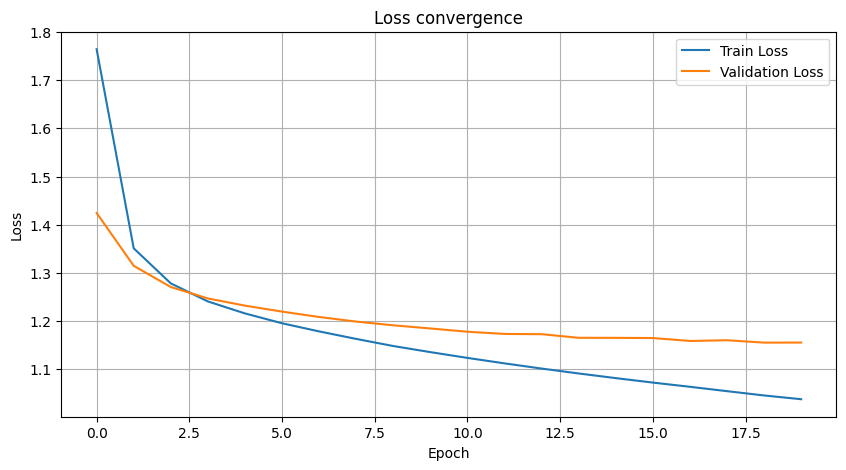

In [ ]:
set_seed(21)
rnn_enc_model = RNN_Encoder(vocab_size=len(eng_dict), embed_dim=64, hidden_size=128)

criterion = nn.CrossEntropyLoss(reduction='mean')
optimizer = torch.optim.AdamW(rnn_enc_model.parameters(),  lr=0.001, weight_decay=1e-3)

train_losses, val_losses = train_encoder(rnn_enc_model, train_loader, val_loader, criterion, optimizer, num_epochs=20)

In [ ]:
name_data['rus_name_to_id'].str.len().max()

14

- c. Generate 10 names using the trained model.

In [ ]:
from torch.nn.functional import softmax

def generate_names(model, alphabet_dict, prefix=None, temperature=0, random_state=21):

  device = "cuda" if torch.cuda.is_available() else 'cpu'
  max_length = 13 # 14 - rus, 13- eng
  model.eval()
  start = 27
  stop = 28
  id_to_char = {v: k for k, v in alphabet_dict.items()}

  if (prefix is None) or (prefix == ""):
    prefix = np.array([start])
  else:
    mapped_prefix = list(map(lambda ch: [alphabet_dict[ch]], prefix.lower()))
    mapped_prefix = [[start]] + mapped_prefix
    prefix = np.array(mapped_prefix).squeeze() # abz > [27,  1,  2, 26]

  # numpy > list
  generated_ids = prefix.tolist()

  input_prefix = torch.from_numpy(prefix).unsqueeze(0).to(device) # (batch_size=1, seq_len)

  g = torch.Generator(device=device)
  if random_state is not None:
    torch.manual_seed(random_state)
    g.manual_seed(random_state)

  with torch.no_grad():
    for _ in range(max_length):
      next_token_logits = model.forward(input_prefix) # output: (1, seq_len=len(prefix), vocab_size)
      last_step_probs = next_token_logits[0, -1, :] # 0 batch elem, last seq_len elem: (vocab_size)

      if temperature == 0:
        next_token = torch.argmax(last_step_probs).item()
      else:
        temp_probs = softmax((last_step_probs / temperature), dim=-1)
        next_token = torch.multinomial(temp_probs, 1, generator=g).item()

      generated_ids.append(next_token)

      if next_token == stop: # "<EOS>"
        break

      input_prefix = torch.tensor([generated_ids], dtype=torch.long, device=device)

  name_tokens = []
  for token_id in generated_ids:
        if token_id == start:
            continue
        if token_id == stop:
            break
        name_tokens.append(id_to_char[token_id])

  generated_name = ''.join(name_tokens)
  return generated_name

In [ ]:
def new_names(model, alphabet_dict):
  prefix_list = ["a", "mi", "el", "ar", "di", "ra", "em", "pu", "ol", "so"]
  new_names = []
  for prefix in prefix_list:
    name = generate_names(model, alphabet_dict, prefix, temperature=0.3)
    new_names.append(name)
  return new_names

In [ ]:
one_layer_enc_list = new_names(rnn_enc_model, eng_dict)
one_layer_enc_list

['arla',
 'michal',
 'elisa',
 'artha',
 'dianna',
 'rayna',
 'emmille',
 'purth',
 'ola',
 'sonna']

# 4. RNN Machine Translation

### a. As Encoder, take the fitted RNN model from the 3rd point.
### b. Implement RNN decoder to produce translation. Use built-in class of neural network library.

In [ ]:
class RNN_Decoder(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_size):
    super().__init__()
    self.hidden_size = hidden_size
    self.emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
    self.rnn = nn.GRU(embed_dim, hidden_size, batch_first=True)
    self.out = nn.Linear(hidden_size, vocab_size)

  def forward(self, x, hidden_state):
    embedded = self.emb(x) # embedded: (B, S, E)
    output, hidden_state = self.rnn(embedded, hidden_state) # hidden_state: (1, B, HS)
    prediction_logits = self.out(output) # prediction_logits: (B, S, VS)
    return prediction_logits, hidden_state

In [ ]:
class MyTranslator(nn.Module):
  def __init__(self, encoder, decoder):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder

    # не будем обучать энкодер
    for param in self.encoder.parameters():
      param.requires_grad = False

  def forward(self, input_seq, target_seq):
    # input_seq: (B, input_seq_len)
    # target_seq: (B, target_seq_len)

    embedded_encoder = self.encoder.emb(input_seq) # (B, IS, EncE)
    _, last_hidden = self.encoder.rnn(embedded_encoder) # (1, B, EncHS)

    # нам не нужно предсказывать токен после <EOS>, а также <SOS>
    # decoder input: (от <SOS> до предпоследнего токена)
    # predict_logits:  (от второго токена до <EOS>)
    prediction_logits, hidden_state = self.decoder(target_seq[:, :-1], last_hidden)

    return prediction_logits # (B, S-1, VS)

In [ ]:
class NameTranslationDataset(Dataset):
  def __init__(self, eng_seqs, rus_seqs):
    self.eng_seqs = torch.tensor(eng_seqs, dtype=torch.long)
    self.rus_seqs = torch.tensor(rus_seqs, dtype=torch.long)

  def __len__(self):
    return len(self.eng_seqs)

  def __getitem__(self, idx):
    return self.eng_seqs[idx], self.rus_seqs[idx]

In [ ]:
def create_translation_datasets(train_df, valid_df, test_df):
  X_train_eng = np.array(train_df["eng_name_to_id"].tolist())
  y_train_rus = np.array(train_df["rus_name_to_id"].tolist())
  train_dataset = NameTranslationDataset(X_train_eng, y_train_rus)

  X_valid_eng = np.array(valid_df["eng_name_to_id"].tolist())
  y_valid_rus = np.array(valid_df["rus_name_to_id"].tolist())
  valid_dataset = NameTranslationDataset(X_valid_eng, y_valid_rus)

  X_test_eng = np.array(test_df["eng_name_to_id"].tolist())
  y_test_rus = np.array(test_df["rus_name_to_id"].tolist())
  test_dataset = NameTranslationDataset(X_test_eng, y_test_rus)

  return train_dataset, valid_dataset, test_dataset

### c. Train the network using loss for next letter prediction. Use early stopping for validation metric. Do not train encoder parameters, train Decoder only.

In [ ]:
def train_seq2seq(model, train_loader, valid_loader, criterion, optimizer, num_epochs, scheduler=None, patience=5, target_lang_vocab_size=None, rus_dict=None):
  train_losses, val_losses = [], []
  device = "cuda" if torch.cuda.is_available() else 'cpu'
  model.to(device)

  best_val_loss = float('inf')
  patience_counter = 0

  for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0
    num_batches_train = 0

    for eng_seq, rus_seq in train_loader:
      eng_seq = eng_seq.to(device)
      rus_seq = rus_seq.to(device)
      optimizer.zero_grad()
      prediction_logits = model(eng_seq, rus_seq) # (B, S-1, VS)

      output_decoder = prediction_logits.reshape(-1, prediction_logits.size(-1)) #  ((B*(S-1)), VS)
      target_decoder = rus_seq[:, 1:].reshape(-1) # (B, S-1)

      loss = criterion(output_decoder, target_decoder)
      loss.backward()
      optimizer.step()

      total_train_loss += loss.item()
      num_batches_train += 1

    avg_train_loss = total_train_loss / num_batches_train
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0.0
    num_batches_val = 0

    with torch.no_grad():
      for eng_seq, rus_seq in valid_loader:
        eng_seq = eng_seq.to(device)
        rus_seq = rus_seq.to(device)

        prediction_logits = model(eng_seq, rus_seq)

        output_decoder = prediction_logits.reshape(-1, prediction_logits.size(-1))
        target_decoder = rus_seq[:, 1:].reshape(-1)

        loss = criterion(output_decoder, target_decoder)

        total_val_loss += loss.item()
        num_batches_val += 1

      avg_val_loss = total_val_loss / num_batches_val
      val_losses.append(avg_val_loss)

      if scheduler is not None:
        scheduler.step(avg_val_loss)

      print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

    # early stopping
    if avg_val_loss < best_val_loss:
      best_val_loss = avg_val_loss
      patience_counter = 0
      # torch.save(model.state_dict(), 'best_seq2seq_model.pth')
    else:
      patience_counter += 1
      print(f'Validation loss did not improve. Patience: {patience_counter}/{patience}')

    if patience_counter >= patience:
      print(f'Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss for {patience} epochs.')
      break

  plt.figure(figsize=(10,5))
  plt.plot(train_losses, label='Train Loss')
  plt.plot(val_losses, label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Loss convergence')
  plt.legend()
  plt.grid(True)
  plt.show()

  return train_losses, val_losses

Epoch 1/20 | Train Loss: 2.6030 | Val Loss: 2.2818
Epoch 2/20 | Train Loss: 2.1861 | Val Loss: 2.1164
Epoch 3/20 | Train Loss: 2.0681 | Val Loss: 2.0437
Epoch 4/20 | Train Loss: 2.0032 | Val Loss: 2.0002
Epoch 5/20 | Train Loss: 1.9561 | Val Loss: 1.9611
Epoch 6/20 | Train Loss: 1.9117 | Val Loss: 1.9316
Epoch 7/20 | Train Loss: 1.8751 | Val Loss: 1.9132
Epoch 8/20 | Train Loss: 1.8442 | Val Loss: 1.8888
Epoch 9/20 | Train Loss: 1.8140 | Val Loss: 1.8672
Epoch 10/20 | Train Loss: 1.7876 | Val Loss: 1.8517
Epoch 11/20 | Train Loss: 1.7598 | Val Loss: 1.8315
Epoch 12/20 | Train Loss: 1.7339 | Val Loss: 1.8179
Epoch 13/20 | Train Loss: 1.7096 | Val Loss: 1.8061
Epoch 14/20 | Train Loss: 1.6866 | Val Loss: 1.8070
Validation loss did not improve. Patience: 1/5
Epoch 15/20 | Train Loss: 1.6657 | Val Loss: 1.7820
Epoch 16/20 | Train Loss: 1.6426 | Val Loss: 1.7719
Epoch 17/20 | Train Loss: 1.6244 | Val Loss: 1.7615
Epoch 18/20 | Train Loss: 1.6063 | Val Loss: 1.7554
Epoch 19/20 | Train Loss: 

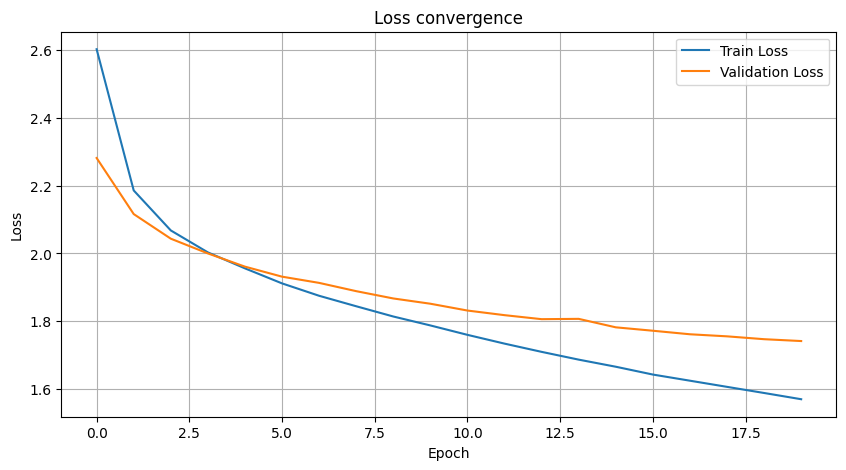

In [ ]:
train_translation_dataset, valid_translation_dataset, test_translation_dataset = create_translation_datasets(train_data, valid_data, test_data)
train_translation_loader = DataLoader(train_translation_dataset, batch_size=64, shuffle=True, generator=g)
val_translation_loader = DataLoader(valid_translation_dataset, batch_size=64, shuffle=False)
test_translation_loader = DataLoader(test_translation_dataset, batch_size=64, shuffle=False)

encoder = rnn_enc_model # уже обученная под задачу генерации имен
decoder = RNN_Decoder(vocab_size=len(rus_dict), embed_dim=64, hidden_size=128)


seq2seq_model = MyTranslator(encoder, decoder)
criterion_seq2seq = nn.CrossEntropyLoss(reduction="mean", ignore_index=rus_dict[' '])
optimizer_seq2seq = torch.optim.AdamW(seq2seq_model.decoder.parameters(), lr=0.001, weight_decay=1e-3)


set_seed(21)
train_losses_seq2seq, val_losses_seq2seq = train_seq2seq(
    seq2seq_model,
    train_translation_loader,
    val_translation_loader,
    criterion_seq2seq,
    optimizer_seq2seq,
    num_epochs=20,
    target_lang_vocab_size=len(rus_dict),
    rus_dict=rus_dict
)

### d. Implement a method to translate the name. Method should not be stochastic — choose next letter with argmax.

In [ ]:
def translate_name(model, english_name, eng_dict, rus_dict, max_len=14):
    model.eval()
    device = "cuda" if torch.cuda.is_available() else 'cpu'
    model.to(device)

    # eng name
    eng_tokens = [eng_dict["<SOS>"]] + [eng_dict[char] for char in english_name.lower()] + [eng_dict["<EOS>"]]
    eng_padded = eng_tokens + [eng_dict[" "]] * (eng_max_len - len(eng_tokens))
    input_tensor = torch.tensor(eng_padded, dtype=torch.long, device=device).unsqueeze(0) # (1, S)

    embedded_encoder = model.encoder.emb(input_tensor)
    encoder_outputs, encoder_hidden = model.encoder.rnn(embedded_encoder)
    # encoder_outputs: (1, S, HS)
    # encoder_hidden: (1, 1, HS)

    decoder_input = torch.tensor([[rus_dict["<SOS>"]]], dtype=torch.long, device=device)
    decoded_tokens = []

    current_decoder_hidden = encoder_hidden

    for _ in range(max_len):
        if isinstance(model.decoder, (RNN_Attention_Decoder, RNN_Attention_Decoder_Positional, RNN_Attention_Decoder_TrainablePositional, RNN_MultiHeadAttention_Decoder)):
            # expects (input_token, encoder_outputs, last_hidden)
            prediction_logits, new_decoder_hidden, _ = model.decoder(decoder_input, encoder_outputs, current_decoder_hidden)
            # prediction_logits: (batch_size, vocab_size)
            next_token_id = prediction_logits.argmax(1).item()
        elif isinstance(model.decoder, (RNN_Decoder, RNN_Decoder_Positional, RNN_Decoder_TrainablePositional)):
            # expects (x, hidden_state)
            prediction_logits_full_seq, new_decoder_hidden = model.decoder(decoder_input, current_decoder_hidden)
            # (batch_size, seq_len=1, vocab_size)
            next_token_id = prediction_logits_full_seq.squeeze(1).argmax(1).item()
        else:
            raise ValueError("Unsupported decoder type")

        if next_token_id == rus_dict["<EOS>"]:
            break

        decoded_tokens.append(next_token_id)
        decoder_input = torch.tensor([[next_token_id]], dtype=torch.long, device=device)
        current_decoder_hidden = new_decoder_hidden

    # ids to chrs
    id_to_char = {v: k for k, v in rus_dict.items()}
    translated_name = ''.join([id_to_char[token_id] for token_id in decoded_tokens if token_id != rus_dict[" "]])

    return translated_name

### e. Evaluation:

- i. Plot loss convergence on train and valid data. - см выше
- ii. Print translation for 5 names from train and 5 names from valid part of dataset every n epochs. Are they realistic?
- iii. Compute perplexity on test set.

In [ ]:
print('English name: John, Русский перевод:', translate_name(seq2seq_model, 'John', eng_dict, rus_dict))
print('English name: William, Русский перевод:', translate_name(seq2seq_model, 'William', eng_dict, rus_dict))
print('English name: James, Русский перевод:', translate_name(seq2seq_model, 'James', eng_dict, rus_dict))
print('English name: Julia, Русский перевод:', translate_name(seq2seq_model, 'Julia', eng_dict, rus_dict))
print('English name: Moana, Русский перевод:', translate_name(seq2seq_model, 'Moana', eng_dict, rus_dict))

English name: John, Русский перевод: джейн
English name: William, Русский перевод: карли
English name: James, Русский перевод: джейси
English name: Julia, Русский перевод: джейла
English name: Moana, Русский перевод: джейка


In [ ]:
def ppl(model, loader):
  device = next(model.parameters()).device
  criterion = nn.CrossEntropyLoss(reduction='mean', ignore_index=rus_dict[' '])

  model.eval()
  total_loss = 0
  num_batches = 0
  with torch.no_grad():
      for eng_seq, rus_seq in loader:
          eng_seq = eng_seq.to(device)
          rus_seq = rus_seq.to(device)
          logits = model(eng_seq, rus_seq)
          loss = criterion(logits.reshape(-1, logits.size(-1)), rus_seq[:, 1:].reshape(-1))
          total_loss += loss.item()
          num_batches +=1

  avg_loss = total_loss / num_batches
  ppl = math.exp(avg_loss)
  print(f"Perplexity: {ppl:.4f}")
  return ppl

In [ ]:
plp_val = ppl(seq2seq_model, val_translation_loader)
plp_test = ppl(seq2seq_model, test_translation_loader)

Perplexity: 5.7058
Perplexity: 5.7323


# 5. Attention Machine Translation

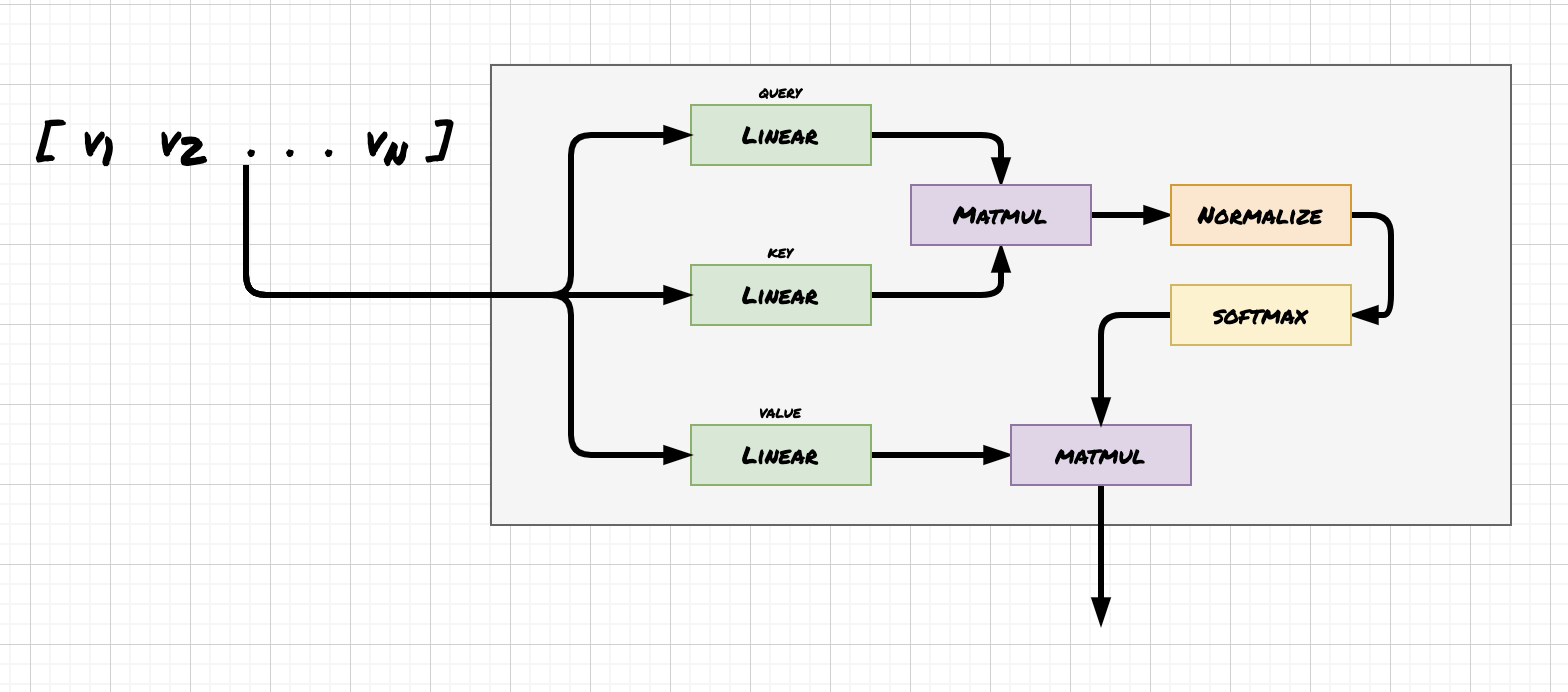

### a. As Encoder, take the fitted RNN model from the 3rd point.
### b. Implement decoder with attention mechanism to produce translation. Do not use the built-in class of the neural network library for Attention. Compute attention between encoder output and decoder input.

In [ ]:
class Attention(nn.Module):
  def __init__(self, hidden_size):
    super().__init__()
    # Bahdanau (https://discuss.pytorch.org/t/implementing-bahdanaus-attention/83557)

    self.Wa = nn.Linear(hidden_size, hidden_size, bias=False)
    self.Ua = nn.Linear(hidden_size, hidden_size, bias=False)
    self.Va = nn.Linear(hidden_size, 1, bias=False)

  def forward(self, encoder_outputs, decoder_hidden):
    # encoder_outputs: (B, S, HS)
    # decoder_hidden: (1, B, HS)

    # (1, B, HS) >  (B, HS) > (B, 1,  HS) > (B*1, 1*S, 1*HS) > (B, S, HS)
    # decoder_hidden_repeated: (B, S, HS)
    decoder_hidden_repeated = decoder_hidden.squeeze(0).unsqueeze(1).repeat(1, encoder_outputs.size(1), 1)

    # scores: (B, S, HS)
    scores = self.Wa(encoder_outputs) + self.Ua(decoder_hidden_repeated)

    # (B, S, 1)
    energy = self.Va(torch.tanh(scores))

    # (B, S)
    attention_weights = F.softmax(energy.squeeze(2), dim=1)

    # (B, S) > (B, 1, S) > (B, 1, S) *(bmm)* (B, S, HS) > (B, 1, HS) > (B, HS)
    # (B, HS)
    context_vector = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs).squeeze(1)
    return context_vector, attention_weights

In [ ]:
class RNN_Attention_Decoder(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_size):
    super().__init__()
    self.hidden_size = hidden_size
    self.vocab_size = vocab_size
    self.embedding = nn.Embedding(vocab_size, embed_dim)
    self.attention = Attention(hidden_size)
    self.rnn = nn.GRU(embed_dim + hidden_size, hidden_size, batch_first=True)
    self.out = nn.Linear(hidden_size, vocab_size)

  def forward(self, input_token, encoder_outputs, last_hidden):
    # input_token: (B, 1)
    # encoder_outputs: (B, EncS, EncHS)
    # last_hidden: (1, B, DecHS)

    embedded = self.embedding(input_token) # (B, 1, E)
    context_vector, attention_weights = self.attention(encoder_outputs, last_hidden) # (B, HS), (B, S)

    # (B, 1, E) + (B, 1, HS) > (B, 1, E + HS)
    rnn_input = torch.cat((embedded, context_vector.unsqueeze(1)), dim=2) # (B, 1, E + HS)

    output, hidden = self.rnn(rnn_input, last_hidden) # output: (B, 1, HS), hidden: (1, B, HS)
    prediction_logits = self.out(output.squeeze(1)) # (B, VS)

    return prediction_logits, hidden, attention_weights

### c. Train the network using loss for next letter prediction. Use early stopping for the validation metric. Do not train Encoder parameters, only Decoder.

In [ ]:
class AttentionSeq2Seq(nn.Module):
  def __init__(self, encoder, decoder):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder

    for param in self.encoder.parameters():
      param.requires_grad = False

  def forward(self, input_seq, target_seq):
    # input_seq: (B, InpS)
    # target_seq: (B, TrgS)
    embedded_encoder = self.encoder.emb(input_seq)

    # encoder_outputs: (B, InpS, HS)
    # last_hidden: (1, B, HS)
    encoder_outputs, last_hidden = self.encoder.rnn(embedded_encoder)

    batch_size = input_seq.size(0)
    target_seq_len = target_seq.size(1) - 1
    decoder_vocab_size = self.decoder.vocab_size

    predictions = torch.zeros(batch_size, target_seq_len, decoder_vocab_size).to(input_seq.device)
    decoder_input = target_seq[:, 0].unsqueeze(1) # (B, 1)
    decoder_hidden = last_hidden

    for t in range(target_seq_len):
        prediction_logits, decoder_hidden, _ = self.decoder(decoder_input, encoder_outputs, decoder_hidden)
        predictions[:, t, :] = prediction_logits
        decoder_input = target_seq[:, t+1].unsqueeze(1) # (B, 1)

    return predictions

Epoch 1/20 | Train Loss: 2.4984 | Val Loss: 2.0701
Epoch 2/20 | Train Loss: 1.7172 | Val Loss: 1.3174
Epoch 3/20 | Train Loss: 0.9091 | Val Loss: 0.7281
Epoch 4/20 | Train Loss: 0.5609 | Val Loss: 0.5616
Epoch 5/20 | Train Loss: 0.4453 | Val Loss: 0.4836
Epoch 6/20 | Train Loss: 0.3803 | Val Loss: 0.4550
Epoch 7/20 | Train Loss: 0.3370 | Val Loss: 0.4231
Epoch 8/20 | Train Loss: 0.3065 | Val Loss: 0.3956
Epoch 9/20 | Train Loss: 0.2779 | Val Loss: 0.3879
Epoch 10/20 | Train Loss: 0.2632 | Val Loss: 0.3796
Epoch 11/20 | Train Loss: 0.2402 | Val Loss: 0.3721
Epoch 12/20 | Train Loss: 0.2272 | Val Loss: 0.3600
Epoch 13/20 | Train Loss: 0.2144 | Val Loss: 0.3670
Validation loss did not improve. Patience: 1/5
Epoch 14/20 | Train Loss: 0.2009 | Val Loss: 0.3620
Validation loss did not improve. Patience: 2/5
Epoch 15/20 | Train Loss: 0.1890 | Val Loss: 0.3598
Epoch 16/20 | Train Loss: 0.1809 | Val Loss: 0.3575
Epoch 17/20 | Train Loss: 0.1686 | Val Loss: 0.3594
Validation loss did not improve

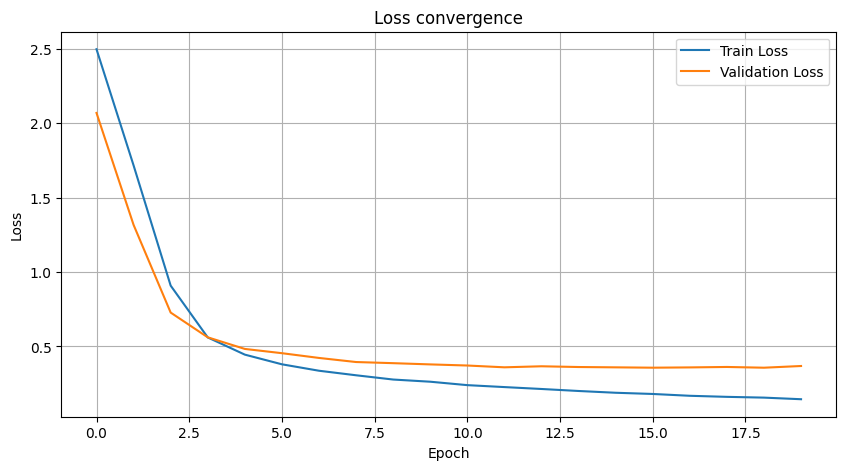

In [ ]:
attention_decoder = RNN_Attention_Decoder(
    vocab_size=len(rus_dict),
    embed_dim=64,
    hidden_size=128
)

attention_seq2seq_model = AttentionSeq2Seq(encoder, attention_decoder)
criterion_attention_seq2seq = nn.CrossEntropyLoss(reduction="mean", ignore_index=rus_dict[' '])
optimizer_attention_seq2seq = torch.optim.AdamW(attention_seq2seq_model.decoder.parameters(), lr=0.001, weight_decay=1e-3)

set_seed(21)
train_losses_attention_seq2seq, val_losses_attention_seq2seq = train_seq2seq(
    attention_seq2seq_model,
    train_translation_loader,
    val_translation_loader,
    criterion_attention_seq2seq,
    optimizer_attention_seq2seq,
    num_epochs=20,
    target_lang_vocab_size=len(rus_dict),
    rus_dict=rus_dict
)

### d. Repeat 4.e for this model.
- графики лосса для train, val - см.выше
- перевод 10 имен и перплексия:

In [ ]:
print('English name: John, Русский перевод:', translate_name(attention_seq2seq_model, 'John', eng_dict, rus_dict))
print('English name: William, Русский перевод:', translate_name(attention_seq2seq_model, 'William', eng_dict, rus_dict))
print('English name: James, Русский перевод:', translate_name(attention_seq2seq_model, 'James', eng_dict, rus_dict))
print('English name: Julia, Русский перевод:', translate_name(attention_seq2seq_model, 'Julia', eng_dict, rus_dict))
print('English name: Moana, Русский перевод:', translate_name(attention_seq2seq_model, 'Moana', eng_dict, rus_dict))

English name: John, Русский перевод: джонн
English name: William, Русский перевод: уильям
English name: James, Русский перевод: джамес
English name: Julia, Русский перевод: джулия
English name: Moana, Русский перевод: моана


In [ ]:
plp_val = ppl(attention_seq2seq_model, val_translation_loader)
plp_test = ppl(attention_seq2seq_model, test_translation_loader)

Perplexity: 1.4461
Perplexity: 1.3755


### e. Compare the results. What can you learn from these results?
- перплексия заметно улучшилась;
- качество перевода стало заметно лучше;
- но имена, где несколько букв в одном языке соответствуют одной букве в другом (и наоборот), все еще сложно переводить.

# 6. Positional Encoding

## a. Implement position encoding using sine and cosine:

### i. Train a separate RNN Encoder with this type of positional coding.

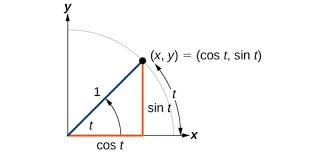

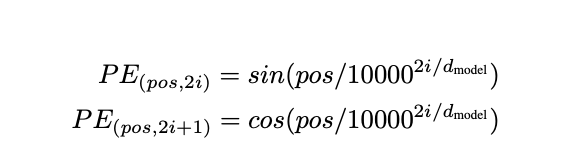

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1) # номера токенов
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))

        # синус для четных и косинус для нечетных
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) # (1, max_len, embed_dim)
        self.register_buffer('pe', pe)

    def forward(self, x):
      # x: (B, S, E)
      return x + self.pe[:, :x.size(1), :]

In [ ]:
class RNN_Encoder_Positional(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_size, max_len):
    super().__init__()
    self.emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
    self.pos_encoder = PositionalEncoding(embed_dim, max_len)
    self.rnn = nn.GRU(embed_dim, hidden_size, batch_first=True)
    self.next_token_fc = nn.Linear(hidden_size, vocab_size)

  def forward(self, x, hidden=None):
    emb = self.emb(x) # emb: (B, S, E)
    emb = self.pos_encoder(emb)
    output, last_hidden = self.rnn(emb, hidden)
    output = self.next_token_fc(output)
    # output: (B, S, V)
    return output

Epoch 1/20 | Train Loss: 2.5865 | Val Loss: 2.3753
Epoch 2/20 | Train Loss: 2.2650 | Val Loss: 2.2379
Epoch 3/20 | Train Loss: 2.1678 | Val Loss: 2.1776
Epoch 4/20 | Train Loss: 2.1121 | Val Loss: 2.1392
Epoch 5/20 | Train Loss: 2.0696 | Val Loss: 2.1136
Epoch 6/20 | Train Loss: 2.0364 | Val Loss: 2.0937
Epoch 7/20 | Train Loss: 2.0074 | Val Loss: 2.0710
Epoch 8/20 | Train Loss: 1.9800 | Val Loss: 2.0632
Epoch 9/20 | Train Loss: 1.9566 | Val Loss: 2.0472
Epoch 10/20 | Train Loss: 1.9347 | Val Loss: 2.0387
Epoch 11/20 | Train Loss: 1.9129 | Val Loss: 2.0265
Epoch 12/20 | Train Loss: 1.8933 | Val Loss: 2.0191
Epoch 13/20 | Train Loss: 1.8744 | Val Loss: 2.0084
Epoch 14/20 | Train Loss: 1.8574 | Val Loss: 2.0115
Validation loss did not improve. Patience: 1/5
Epoch 15/20 | Train Loss: 1.8399 | Val Loss: 2.0034
Epoch 16/20 | Train Loss: 1.8221 | Val Loss: 2.0029
Epoch 17/20 | Train Loss: 1.8078 | Val Loss: 1.9998
Epoch 18/20 | Train Loss: 1.7928 | Val Loss: 1.9971
Epoch 19/20 | Train Loss: 

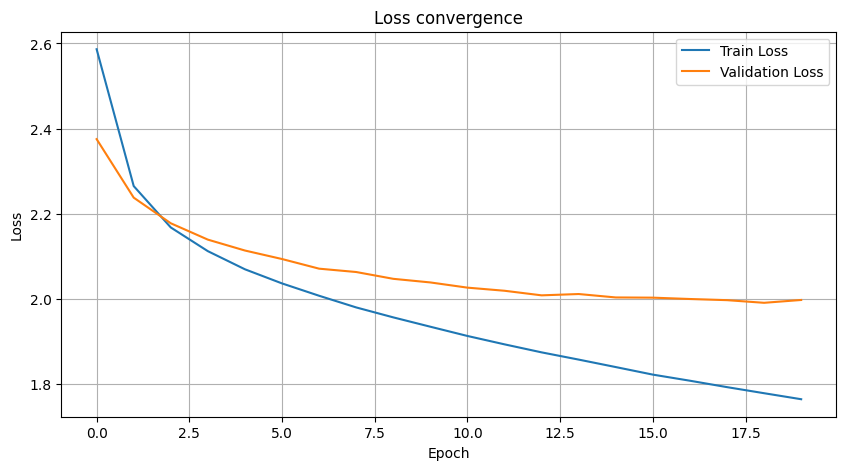

In [ ]:
set_seed(21)
rnn_enc_pos_model = RNN_Encoder_Positional(vocab_size=len(eng_dict), embed_dim=64, hidden_size=128, max_len=eng_max_len)

criterion = nn.CrossEntropyLoss(reduction="mean", ignore_index=rus_dict[' '])
optimizer = torch.optim.AdamW(rnn_enc_pos_model.parameters(),  lr=0.001, weight_decay=1e-3)

train_losses_pos_enc, val_losses_pos_enc = train_encoder(rnn_enc_pos_model, train_loader, val_loader, criterion, optimizer, num_epochs=20)

### ii. Train RNN Decoder for Machine Translation with this type of positional encoding.

In [ ]:
class RNN_Decoder_Positional(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_size, max_len):
    super().__init__()
    self.hidden_size = hidden_size
    self.emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
    self.pos_encoder = PositionalEncoding(embed_dim, max_len)
    self.rnn = nn.GRU(embed_dim, hidden_size, batch_first=True)
    self.out = nn.Linear(hidden_size, vocab_size)

  def forward(self, x, hidden_state):
    embedded = self.emb(x)
    embedded_with_pos = self.pos_encoder(embedded)
    output, hidden_state = self.rnn(embedded_with_pos, hidden_state)
    prediction_logits = self.out(output)
    # prediction_logits: (B, S, VS)
    return prediction_logits, hidden_state

Epoch 1/20 | Train Loss: 2.5941 | Val Loss: 2.2861
Epoch 2/20 | Train Loss: 2.1654 | Val Loss: 2.0675
Epoch 3/20 | Train Loss: 1.9921 | Val Loss: 1.9514
Epoch 4/20 | Train Loss: 1.8867 | Val Loss: 1.8795
Epoch 5/20 | Train Loss: 1.8166 | Val Loss: 1.8286
Epoch 6/20 | Train Loss: 1.7644 | Val Loss: 1.7948
Epoch 7/20 | Train Loss: 1.7176 | Val Loss: 1.7563
Epoch 8/20 | Train Loss: 1.6753 | Val Loss: 1.7223
Epoch 9/20 | Train Loss: 1.6403 | Val Loss: 1.7062
Epoch 10/20 | Train Loss: 1.6025 | Val Loss: 1.6689
Epoch 11/20 | Train Loss: 1.5694 | Val Loss: 1.6426
Epoch 12/20 | Train Loss: 1.5402 | Val Loss: 1.6351
Epoch 13/20 | Train Loss: 1.5126 | Val Loss: 1.6110
Epoch 14/20 | Train Loss: 1.4818 | Val Loss: 1.5932
Epoch 15/20 | Train Loss: 1.4558 | Val Loss: 1.5775
Epoch 16/20 | Train Loss: 1.4309 | Val Loss: 1.5607
Epoch 17/20 | Train Loss: 1.4070 | Val Loss: 1.5465
Epoch 18/20 | Train Loss: 1.3865 | Val Loss: 1.5414
Epoch 19/20 | Train Loss: 1.3604 | Val Loss: 1.5204
Epoch 20/20 | Train L

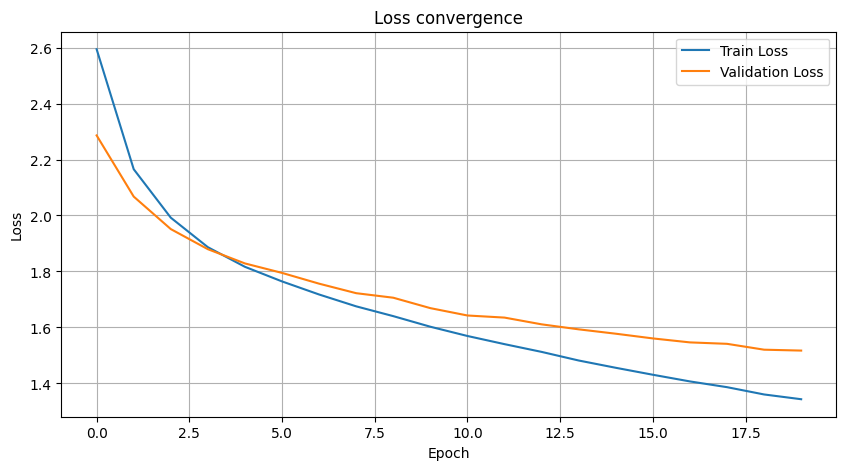

In [ ]:
pos_enc_encoder = rnn_enc_pos_model
pos_enc_decoder = RNN_Decoder_Positional(vocab_size=len(rus_dict), embed_dim=64, hidden_size=128, max_len=rus_max_len)
seq2seq_pos_enc_model = MyTranslator(pos_enc_encoder, pos_enc_decoder)

criterion_seq2seq_pos_enc = nn.CrossEntropyLoss(reduction="mean", ignore_index=rus_dict[' '])
optimizer_seq2seq_pos_enc = torch.optim.AdamW(seq2seq_pos_enc_model.decoder.parameters(), lr=0.001, weight_decay=1e-3)

set_seed(21)

train_losses_seq2seq_pos_enc, val_losses_seq2seq_pos_enc = train_seq2seq(
    seq2seq_pos_enc_model,
    train_translation_loader,
    val_translation_loader,
    criterion_seq2seq_pos_enc,
    optimizer_seq2seq_pos_enc,
    num_epochs=20,
    target_lang_vocab_size=len(rus_dict),
    rus_dict=rus_dict
)

- Evaluation for RNN-Decoder with Positional Encoding

In [ ]:
print('English name: John, Русский перевод:', translate_name(seq2seq_pos_enc_model, 'John', eng_dict, rus_dict))
print('English name: William, Русский перевод:', translate_name(seq2seq_pos_enc_model, 'William', eng_dict, rus_dict))
print('English name: James, Русский перевод:', translate_name(seq2seq_pos_enc_model, 'James', eng_dict, rus_dict))
print('English name: Julia, Русский перевод:', translate_name(seq2seq_pos_enc_model, 'Julia', eng_dict, rus_dict))
print('English name: Moana, Русский перевод:', translate_name(seq2seq_pos_enc_model, 'Moana', eng_dict, rus_dict))

English name: John, Русский перевод: джамман
English name: William, Русский перевод: марилланан
English name: James, Русский перевод: джамина
English name: Julia, Русский перевод: лилия
English name: Moana, Русский перевод: джамикайа


In [ ]:
print("Perplexity for Attention Decoder with Positional Encoding (Validation Set):")
plp_val_att_pos_enc = ppl(seq2seq_pos_enc_model, val_translation_loader)
print("Perplexity for Attention Decoder with Positional Encoding (Test Set):")
plp_test_att_pos_enc = ppl(seq2seq_pos_enc_model, test_translation_loader)

Perplexity for Attention Decoder with Positional Encoding (Validation Set):
Perplexity: 4.5596
Perplexity for Attention Decoder with Positional Encoding (Test Set):
Perplexity: 4.6988


### iii. Train Attention Decoder for Machine Translation with this type of positional encoding.

In [ ]:
class RNN_Attention_Decoder_Positional(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_size, max_len):
    super().__init__()
    self.hidden_size = hidden_size
    self.vocab_size = vocab_size
    self.embedding = nn.Embedding(vocab_size, embed_dim)
    self.pos_encoder = PositionalEncoding(embed_dim, max_len)
    self.attention = Attention(hidden_size)
    self.rnn = nn.GRU(embed_dim + hidden_size, hidden_size, batch_first=True)
    self.out = nn.Linear(hidden_size, vocab_size)

  def forward(self, input_token, encoder_outputs, last_hidden):
    embedded = self.embedding(input_token)
    embedded_with_pos = self.pos_encoder(embedded)

    context_vector, attention_weights = self.attention(encoder_outputs, last_hidden)
    rnn_input = torch.cat((embedded_with_pos, context_vector.unsqueeze(1)), dim=2)
    output, hidden = self.rnn(rnn_input, last_hidden)
    prediction_logits = self.out(output.squeeze(1))
    return prediction_logits, hidden, attention_weights

Epoch 1/20 | Train Loss: 2.4651 | Val Loss: 2.0126
Epoch 2/20 | Train Loss: 1.6411 | Val Loss: 1.2861
Epoch 3/20 | Train Loss: 0.9704 | Val Loss: 0.8174
Epoch 4/20 | Train Loss: 0.6515 | Val Loss: 0.6332
Epoch 5/20 | Train Loss: 0.5158 | Val Loss: 0.5372
Epoch 6/20 | Train Loss: 0.4317 | Val Loss: 0.5057
Epoch 7/20 | Train Loss: 0.3819 | Val Loss: 0.4614
Epoch 8/20 | Train Loss: 0.3410 | Val Loss: 0.4418
Epoch 9/20 | Train Loss: 0.3087 | Val Loss: 0.4339
Epoch 10/20 | Train Loss: 0.2849 | Val Loss: 0.4058
Epoch 11/20 | Train Loss: 0.2619 | Val Loss: 0.4106
Validation loss did not improve. Patience: 1/5
Epoch 12/20 | Train Loss: 0.2484 | Val Loss: 0.3932
Epoch 13/20 | Train Loss: 0.2247 | Val Loss: 0.3885
Epoch 14/20 | Train Loss: 0.2095 | Val Loss: 0.3919
Validation loss did not improve. Patience: 1/5
Epoch 15/20 | Train Loss: 0.2028 | Val Loss: 0.4105
Validation loss did not improve. Patience: 2/5
Epoch 16/20 | Train Loss: 0.1930 | Val Loss: 0.3886
Validation loss did not improve. Pat

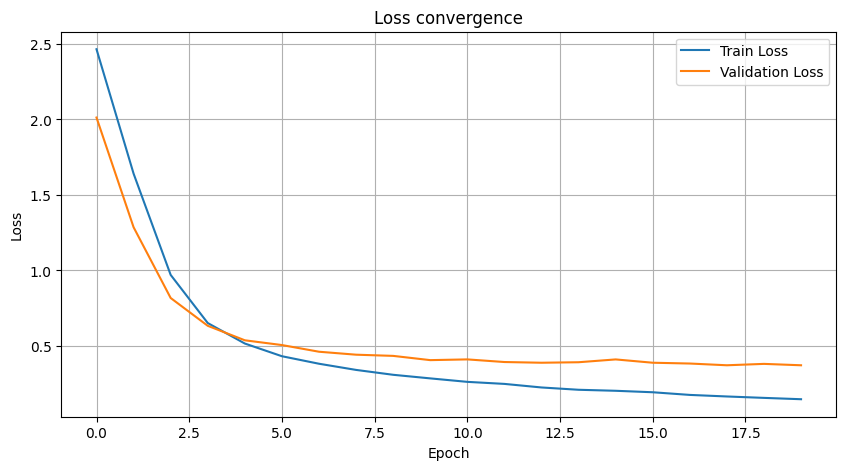

In [ ]:
pos_enc_attention_encoder = rnn_enc_pos_model


pos_enc_attention_decoder = RNN_Attention_Decoder_Positional(vocab_size=len(rus_dict),embed_dim=64,hidden_size=128,max_len=rus_max_len)
attention_seq2seq_pos_enc_model = AttentionSeq2Seq(pos_enc_attention_encoder, pos_enc_attention_decoder)

criterion_attention_seq2seq_pos_enc = nn.CrossEntropyLoss(reduction="mean", ignore_index=rus_dict[' '])
optimizer_attention_seq2seq_pos_enc = torch.optim.AdamW(attention_seq2seq_pos_enc_model.decoder.parameters(), lr=0.001, weight_decay=1e-3)

set_seed(21)
train_losses_attention_seq2seq_pos_enc, val_losses_attention_seq2seq_pos_enc = train_seq2seq(
    attention_seq2seq_pos_enc_model,
    train_translation_loader,
    val_translation_loader,
    criterion_attention_seq2seq_pos_enc,
    optimizer_attention_seq2seq_pos_enc,
    num_epochs=20,
    target_lang_vocab_size=len(rus_dict),
    rus_dict=rus_dict
)

- Evaluation for Attention Decoder with Positional Encoding

In [ ]:
print('English name: John, Русский перевод:', translate_name(attention_seq2seq_pos_enc_model, 'John', eng_dict, rus_dict))
print('English name: William, Русский перевод:', translate_name(attention_seq2seq_pos_enc_model, 'William', eng_dict, rus_dict))
print('English name: James, Русский перевод:', translate_name(attention_seq2seq_pos_enc_model, 'James', eng_dict, rus_dict))
print('English name: Julia, Русский перевод:', translate_name(attention_seq2seq_pos_enc_model, 'Julia', eng_dict, rus_dict))
print('English name: Moana, Русский перевод:', translate_name(attention_seq2seq_pos_enc_model, 'Moana', eng_dict, rus_dict))

English name: John, Русский перевод: джонн
English name: William, Русский перевод: уильям
English name: James, Русский перевод: джеймс
English name: Julia, Русский перевод: джулия
English name: Moana, Русский перевод: мауна


In [ ]:
print("Perplexity for Attention Decoder with Positional Encoding (Validation Set):")
plp_val_att_pos_enc = ppl(attention_seq2seq_pos_enc_model, val_translation_loader)
print("Perplexity for Attention Decoder with Positional Encoding (Test Set):")
plp_test_att_pos_enc = ppl(attention_seq2seq_pos_enc_model, test_translation_loader)

Perplexity for Attention Decoder with Positional Encoding (Validation Set):
Perplexity: 1.4503
Perplexity for Attention Decoder with Positional Encoding (Test Set):
Perplexity: 1.3911


- iv. Evaluate models and compare results. Make local inferences about the results.

- значения перплексии и качество перевода см. выше.
- перевод стал лучше, даже имена, где несколько букв в одном языке соответствуют одной в другом языке (джеймс)

## b. Implement position encoding with trainable weights:

- i. Repeat steps 6.a.i–6.a.iii for this positional encoding.
- ii. Visualize the learned positional encoding.


In [ ]:
class TrainablePositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=5000):
      super().__init__()
      self.position_embeddings = nn.Embedding(max_len, embed_dim)

    def forward(self, x):
      # x: (B, S, E)
      seq_len = x.size(1)
      positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand_as(x[:,:,0])
      # positions: (B, S)
      return x + self.position_embeddings(positions)

### Train RNN Encoder with Trainable Positional Encoding

In [ ]:
class RNN_Encoder_TrainablePositional(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_size, max_len):
    super().__init__()
    self.emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
    self.pos_encoder = TrainablePositionalEncoding(embed_dim, max_len)
    self.rnn = nn.GRU(embed_dim, hidden_size, batch_first=True)
    self.next_token_fc = nn.Linear(hidden_size, vocab_size)

  def forward(self, x, hidden=None):
    emb = self.emb(x)
    emb = self.pos_encoder(emb)
    output, last_hidden = self.rnn(emb, hidden)
    output = self.next_token_fc(output)
    return output

Epoch 1/20 | Train Loss: 2.5997 | Val Loss: 2.3813
Epoch 2/20 | Train Loss: 2.2692 | Val Loss: 2.2465
Epoch 3/20 | Train Loss: 2.1733 | Val Loss: 2.1862
Epoch 4/20 | Train Loss: 2.1182 | Val Loss: 2.1513
Epoch 5/20 | Train Loss: 2.0763 | Val Loss: 2.1244
Epoch 6/20 | Train Loss: 2.0428 | Val Loss: 2.1066
Epoch 7/20 | Train Loss: 2.0120 | Val Loss: 2.0901
Epoch 8/20 | Train Loss: 1.9845 | Val Loss: 2.0784
Epoch 9/20 | Train Loss: 1.9604 | Val Loss: 2.0649
Epoch 10/20 | Train Loss: 1.9351 | Val Loss: 2.0567
Epoch 11/20 | Train Loss: 1.9148 | Val Loss: 2.0481
Epoch 12/20 | Train Loss: 1.8920 | Val Loss: 2.0475
Epoch 13/20 | Train Loss: 1.8746 | Val Loss: 2.0347
Epoch 14/20 | Train Loss: 1.8537 | Val Loss: 2.0260
Epoch 15/20 | Train Loss: 1.8364 | Val Loss: 2.0322
Validation loss did not improve. Patience: 1/5
Epoch 16/20 | Train Loss: 1.8203 | Val Loss: 2.0209
Epoch 17/20 | Train Loss: 1.8032 | Val Loss: 2.0228
Validation loss did not improve. Patience: 1/5
Epoch 18/20 | Train Loss: 1.787

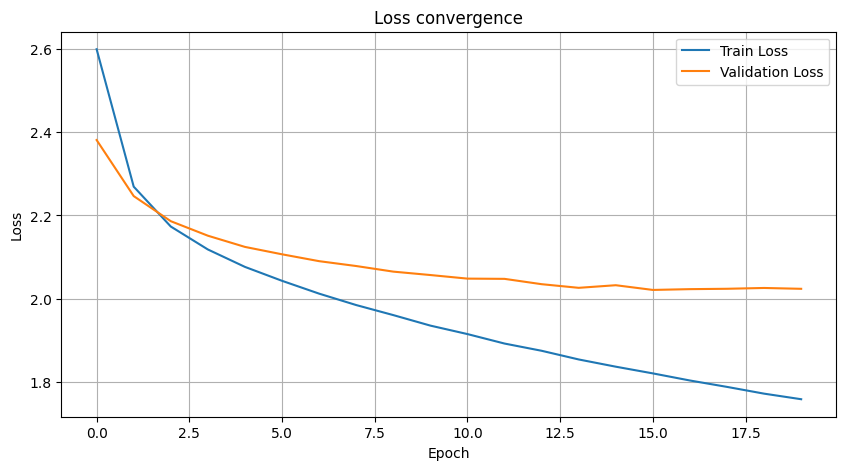

In [ ]:
set_seed(21)
rnn_enc_trainable_pos_model = RNN_Encoder_TrainablePositional(vocab_size=len(eng_dict), embed_dim=64, hidden_size=128, max_len=eng_max_len)

criterion =  nn.CrossEntropyLoss(reduction="mean", ignore_index=rus_dict[' '])
optimizer = torch.optim.AdamW(rnn_enc_trainable_pos_model.parameters(),  lr=0.001, weight_decay=1e-3)

train_losses_trainable_pos_enc, val_losses_trainable_pos_enc = train_encoder(rnn_enc_trainable_pos_model, train_loader, val_loader, criterion, optimizer, num_epochs=20)

### Train RNN Decoder for Machine Translation with Trainable Positional Encoding

In [ ]:
class RNN_Decoder_TrainablePositional(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_size, max_len):
    super().__init__()
    self.hidden_size = hidden_size
    self.emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
    self.pos_encoder = TrainablePositionalEncoding(embed_dim, max_len)
    self.rnn = nn.GRU(embed_dim, hidden_size, batch_first=True)
    self.out = nn.Linear(hidden_size, vocab_size)

  def forward(self, x, hidden_state):
    embedded = self.emb(x)
    embedded_with_pos = self.pos_encoder(embedded)
    output, hidden_state = self.rnn(embedded_with_pos, hidden_state)
    prediction_logits = self.out(output)
    return prediction_logits, hidden_state

Epoch 1/20 | Train Loss: 2.5936 | Val Loss: 2.3015
Epoch 2/20 | Train Loss: 2.2102 | Val Loss: 2.1457
Epoch 3/20 | Train Loss: 2.0844 | Val Loss: 2.0526
Epoch 4/20 | Train Loss: 1.9738 | Val Loss: 1.9477
Epoch 5/20 | Train Loss: 1.8747 | Val Loss: 1.8754
Epoch 6/20 | Train Loss: 1.7998 | Val Loss: 1.8350
Epoch 7/20 | Train Loss: 1.7440 | Val Loss: 1.7902
Epoch 8/20 | Train Loss: 1.6929 | Val Loss: 1.7513
Epoch 9/20 | Train Loss: 1.6466 | Val Loss: 1.7252
Epoch 10/20 | Train Loss: 1.6066 | Val Loss: 1.7149
Epoch 11/20 | Train Loss: 1.5731 | Val Loss: 1.6756
Epoch 12/20 | Train Loss: 1.5336 | Val Loss: 1.6664
Epoch 13/20 | Train Loss: 1.5031 | Val Loss: 1.6381
Epoch 14/20 | Train Loss: 1.4701 | Val Loss: 1.6244
Epoch 15/20 | Train Loss: 1.4435 | Val Loss: 1.6063
Epoch 16/20 | Train Loss: 1.4137 | Val Loss: 1.5897
Epoch 17/20 | Train Loss: 1.3928 | Val Loss: 1.5874
Epoch 18/20 | Train Loss: 1.3667 | Val Loss: 1.5679
Epoch 19/20 | Train Loss: 1.3462 | Val Loss: 1.5554
Epoch 20/20 | Train L

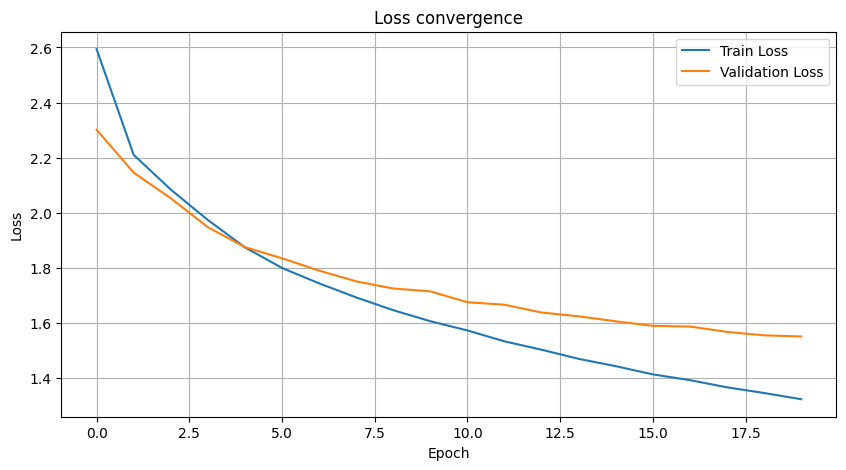

In [ ]:
trainable_pos_enc_encoder = rnn_enc_trainable_pos_model
trainable_pos_enc_decoder = RNN_Decoder_TrainablePositional(vocab_size=len(rus_dict), embed_dim=64, hidden_size=128, max_len=rus_max_len)
seq2seq_trainable_pos_enc_model = MyTranslator(trainable_pos_enc_encoder, trainable_pos_enc_decoder)

criterion_seq2seq_trainable_pos_enc = nn.CrossEntropyLoss(reduction="mean", ignore_index=rus_dict[' '])
optimizer_seq2seq_trainable_pos_enc = torch.optim.AdamW(seq2seq_trainable_pos_enc_model.decoder.parameters(), lr=0.001, weight_decay=1e-3)

set_seed(21)
train_losses_seq2seq_trainable_pos_enc, val_losses_seq2seq_trainable_pos_enc = train_seq2seq(
    seq2seq_trainable_pos_enc_model,
    train_translation_loader,
    val_translation_loader,
    criterion_seq2seq_trainable_pos_enc,
    optimizer_seq2seq_trainable_pos_enc,
    num_epochs=20,
    target_lang_vocab_size=len(rus_dict),
    rus_dict=rus_dict
)

### Evaluation for RNN Decoder with Trainable Positional Encoding

In [ ]:
print('English name: John, Русский перевод:', translate_name(seq2seq_trainable_pos_enc_model, 'John', eng_dict, rus_dict))
print('English name: William, Русский перевод:', translate_name(seq2seq_trainable_pos_enc_model, 'William', eng_dict, rus_dict))
print('English name: James, Русский перевод:', translate_name(seq2seq_trainable_pos_enc_model, 'James', eng_dict, rus_dict))
print('English name: Julia, Русский перевод:', translate_name(seq2seq_trainable_pos_enc_model, 'Julia', eng_dict, rus_dict))
print('English name: Moana, Русский перевод:', translate_name(seq2seq_trainable_pos_enc_model, 'Moana', eng_dict, rus_dict))

English name: John, Русский перевод: джимисимифисиф
English name: William, Русский перевод: алимисимимимуи
English name: James, Русский перевод: эмиомисибиурид
English name: Julia, Русский перевод: лианиариалиааа
English name: Moana, Русский перевод: лимарианаиараа


In [ ]:
print("Perplexity for RNN Decoder with Trainable Positional Encoding (Validation Set):")
plp_val_trainable_pos_enc = ppl(seq2seq_trainable_pos_enc_model, val_translation_loader)
print("Perplexity for RNN Decoder with Trainable Positional Encoding (Test Set):")
plp_test_trainable_pos_enc = ppl(seq2seq_trainable_pos_enc_model, test_translation_loader)

Perplexity for RNN Decoder with Trainable Positional Encoding (Validation Set):
Perplexity: 4.7175
Perplexity for RNN Decoder with Trainable Positional Encoding (Test Set):
Perplexity: 4.7056


### Train Attention Decoder for Machine Translation with Trainable Positional Encoding

In [ ]:
class RNN_Attention_Decoder_TrainablePositional(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_size, max_len):
    super().__init__()
    self.hidden_size = hidden_size
    self.vocab_size = vocab_size
    self.embedding = nn.Embedding(vocab_size, embed_dim)
    self.pos_encoder = TrainablePositionalEncoding(embed_dim, max_len)
    self.attention = Attention(hidden_size)
    self.rnn = nn.GRU(embed_dim + hidden_size, hidden_size, batch_first=True)
    self.out = nn.Linear(hidden_size, vocab_size)

  def forward(self, input_token, encoder_outputs, last_hidden):
    embedded = self.embedding(input_token)
    embedded_with_pos = self.pos_encoder(embedded)
    context_vector, attention_weights = self.attention(encoder_outputs, last_hidden)
    rnn_input = torch.cat((embedded_with_pos, context_vector.unsqueeze(1)), dim=2)
    output, hidden = self.rnn(rnn_input, last_hidden)
    prediction_logits = self.out(output.squeeze(1))
    return prediction_logits, hidden, attention_weights

Epoch 1/20 | Train Loss: 2.4536 | Val Loss: 1.9607
Epoch 2/20 | Train Loss: 1.5516 | Val Loss: 1.1722
Epoch 3/20 | Train Loss: 0.9104 | Val Loss: 0.8112
Epoch 4/20 | Train Loss: 0.6449 | Val Loss: 0.6316
Epoch 5/20 | Train Loss: 0.5104 | Val Loss: 0.5536
Epoch 6/20 | Train Loss: 0.4381 | Val Loss: 0.5172
Epoch 7/20 | Train Loss: 0.3897 | Val Loss: 0.4861
Epoch 8/20 | Train Loss: 0.3522 | Val Loss: 0.4475
Epoch 9/20 | Train Loss: 0.3213 | Val Loss: 0.4346
Epoch 10/20 | Train Loss: 0.2876 | Val Loss: 0.4216
Epoch 11/20 | Train Loss: 0.2661 | Val Loss: 0.4069
Epoch 12/20 | Train Loss: 0.2491 | Val Loss: 0.4013
Epoch 13/20 | Train Loss: 0.2372 | Val Loss: 0.3924
Epoch 14/20 | Train Loss: 0.2189 | Val Loss: 0.3921
Epoch 15/20 | Train Loss: 0.2047 | Val Loss: 0.3943
Validation loss did not improve. Patience: 1/5
Epoch 16/20 | Train Loss: 0.1919 | Val Loss: 0.3845
Epoch 17/20 | Train Loss: 0.1846 | Val Loss: 0.3815
Epoch 18/20 | Train Loss: 0.1750 | Val Loss: 0.3851
Validation loss did not im

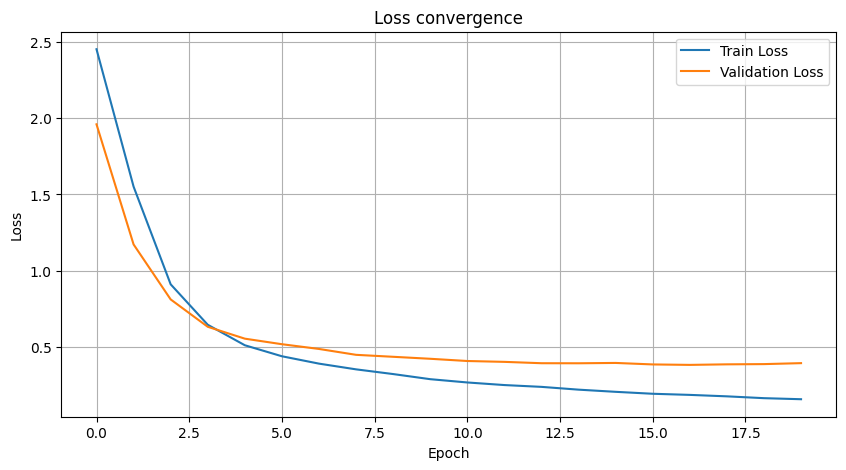

In [ ]:
trainable_pos_enc_attention_encoder = rnn_enc_trainable_pos_model
trainable_pos_enc_attention_decoder = RNN_Attention_Decoder_TrainablePositional(
    vocab_size=len(rus_dict),
    embed_dim=64,
    hidden_size=128,
    max_len=rus_max_len
)

attention_seq2seq_trainable_pos_enc_model = AttentionSeq2Seq(trainable_pos_enc_attention_encoder, trainable_pos_enc_attention_decoder)

criterion_attention_seq2seq_trainable_pos_enc = nn.CrossEntropyLoss(reduction="mean", ignore_index=rus_dict[' '])
optimizer_attention_seq2seq_trainable_pos_enc = torch.optim.AdamW(attention_seq2seq_trainable_pos_enc_model.decoder.parameters(), lr=0.001, weight_decay=1e-3)

set_seed(21)
train_losses_attention_seq2seq_trainable_pos_enc, val_losses_attention_seq2seq_trainable_pos_enc = train_seq2seq(
    attention_seq2seq_trainable_pos_enc_model,
    train_translation_loader,
    val_translation_loader,
    criterion_attention_seq2seq_trainable_pos_enc,
    optimizer_attention_seq2seq_trainable_pos_enc,
    num_epochs=20,
    target_lang_vocab_size=len(rus_dict),
    rus_dict=rus_dict
)

### Evaluation for Attention Decoder with Trainable Positional Encoding

In [ ]:
print('English name: John, Русский перевод:', translate_name(attention_seq2seq_trainable_pos_enc_model, 'John', eng_dict, rus_dict))
print('English name: William, Русский перевод:', translate_name(attention_seq2seq_trainable_pos_enc_model, 'William', eng_dict, rus_dict))
print('English name: James, Русский перевод:', translate_name(attention_seq2seq_trainable_pos_enc_model, 'James', eng_dict, rus_dict))
print('English name: Julia, Русский перевод:', translate_name(attention_seq2seq_trainable_pos_enc_model, 'Julia', eng_dict, rus_dict))
print('English name: Moana, Русский перевод:', translate_name(attention_seq2seq_trainable_pos_enc_model, 'Moana', eng_dict, rus_dict))

English name: John, Русский перевод: джонн
English name: William, Русский перевод: виллима
English name: James, Русский перевод: джеймс
English name: Julia, Русский перевод: джулия
English name: Moana, Русский перевод: моэна


In [ ]:
print("Perplexity for Attention Decoder with Trainable Positional Encoding (Validation Set):")
plp_val_att_trainable_pos_enc = ppl(attention_seq2seq_trainable_pos_enc_model, val_translation_loader)
print("Perplexity for Attention Decoder with Trainable Positional Encoding (Test Set):")
plp_test_att_trainable_pos_enc = ppl(attention_seq2seq_trainable_pos_enc_model, test_translation_loader)

Perplexity for Attention Decoder with Trainable Positional Encoding (Validation Set):
Perplexity: 1.4813
Perplexity for Attention Decoder with Trainable Positional Encoding (Test Set):
Perplexity: 1.4157


## c. What are the advantages and disadvantages of using sine and cosine positional encoding instead of trainable weight positional encoding? Give the answer.

#### Преимущества sin/cos PE:
- меньше параметров для обучения > более легкая модель, относительно более быстрая сходимость, меньше вычислительных ресурсов, меньше риск переобучения;
- синус/косинус кодирование работает для любой позиции (даже > max_len - можно считать позиционные коэффициенты на лету по формуле, а не хранить значения в таблице), в случае обучаемого есть ограничение из-за создания фиксированной матрицы nn.Embedding ровно из max_len векторов перед обучением. Если увеличиваем размер - все надо переобучать;
- благодаря тригонометрическим тождествам, PE(pos+k) может быть выражен как линейная функция от PE(pos), что позволяет модели легче обобщать относительные расстояния между токенами, не вычисляя абсолютные.

#### Недостатки sin/cos PE:
- неэффективность для задач, где важен абсолютный порядок, а не относительный (порядок слов в предложении);
- неадаптивность под данные (например, в случае имен первый символ может быть важнее следующих - но sin PE не умеет это подчеркивать);
- все частоты от низких до высоких исп-ся с одинаковым весом  - нельзя занулить ненужные размерности;
- сложности с интерпретацией - непонятно, какое измерение что кодирует.

# 7. Multi-head Attention Machine Translation

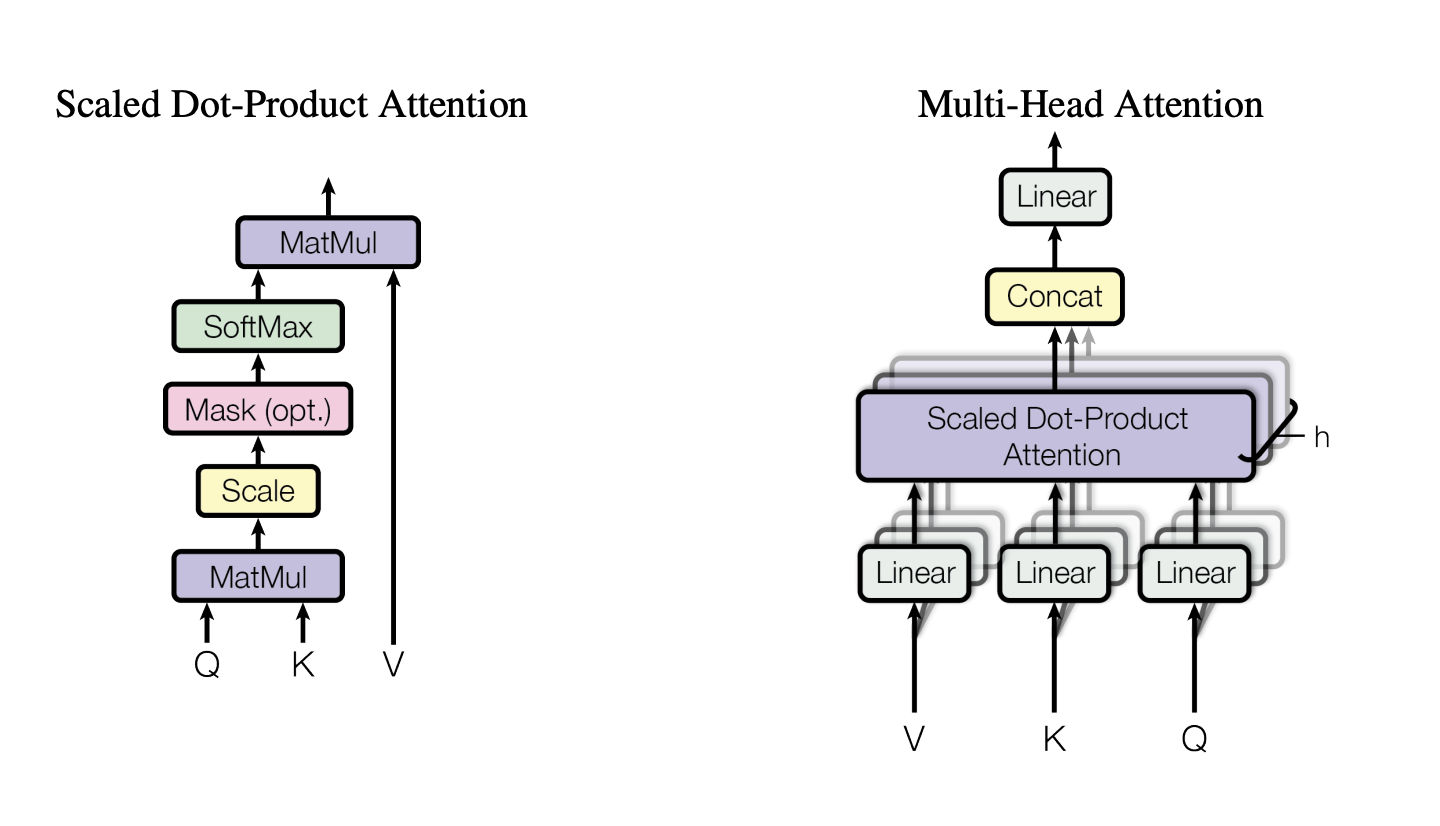

### a. Implement Multi-head attention. Use n_heads = 3.

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_size, n_heads=3):
        super().__init__()
        assert hidden_size % n_heads == 0
        self.hidden_size = hidden_size
        self.n_heads = n_heads
        self.head_dim = hidden_size // n_heads

        self.W_q = nn.Linear(hidden_size, hidden_size)
        self.W_k = nn.Linear(hidden_size, hidden_size)
        self.W_v = nn.Linear(hidden_size, hidden_size)

        self.fc_out = nn.Linear(hidden_size, hidden_size)

    def forward(self, query, key, value, mask=None):
        # query, key, value: (B, S, HS)
        batch_size = query.shape[0]

        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        # (B, S, HS) > (B, S, n_heads, head_dim) > (B, n_heads, S, head_dim)
        Q = Q.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3) # (B, n_heads, S, head_dim)
        K = K.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
        V = V.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)

        # (B, n_heads, S, head_dim) > (B, n_heads, head_dim, S=key_len)
        # (B, n_heads, S=query_len, head_dim) * (B, n_heads, head_dim, S=key_len) > (B, n_heads, S, S)
        energy = torch.matmul(Q, K.permute(0, 1, 3, 2)) / math.sqrt(self.head_dim) # (B, n_heads, S=query_len, S=key_len)

        if mask is not None:
            # mask: (B, 1, S=query_len, S=key_len) or (B, 1, 1, S=key_len)
            energy = energy.masked_fill(mask == 0, -1e10)

        attention = torch.softmax(energy, dim=-1) # (B, n_heads, S=query_len, S=key_len)

        # (B, n_heads, S=query_len, S=key_len) * (B, n_heads, S=value_len=key_len, head_dim)
        x = torch.matmul(attention, V) # (B, n_heads, query_len, head_dim)
        x = x.permute(0, 2, 1, 3).contiguous() # (B, query_len, n_heads, head_dim)
        x = x.view(batch_size, -1, self.n_heads * self.head_dim)  # (B, query_len, n_heads*head_dim = HS)
        # (B, query_len, HS)

        x = self.fc_out(x)
        return x, attention

In [ ]:
class RNN_MultiHeadAttention_Decoder(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_size, n_heads=3, max_len=5000):
    super().__init__()
    self.hidden_size = hidden_size
    self.vocab_size = vocab_size
    self.embedding = nn.Embedding(vocab_size, embed_dim)
    self.pos_encoder = PositionalEncoding(embed_dim, max_len)
    self.multi_head_attention = MultiHeadAttention(hidden_size, n_heads)
    self.rnn = nn.GRU(embed_dim + hidden_size, hidden_size, batch_first=True)
    self.out = nn.Linear(hidden_size, vocab_size)

  def forward(self, input_token, encoder_outputs, last_hidden):
    embedded = self.embedding(input_token)
    embedded_with_pos = self.pos_encoder(embedded) # POS-encoding

    query = last_hidden.permute(1, 0, 2) # (B, 1, HS)
    context_vector, attention_weights = self.multi_head_attention(query, encoder_outputs, encoder_outputs)
    # context_vector: (B, 1, HS)
    # attention_weights: (B, n_heads, 1, EncS)

    rnn_input = torch.cat((embedded_with_pos, context_vector), dim=2)
    # context_vector: (B, 1, HS)

    output, hidden = self.rnn(rnn_input, last_hidden)
    # output: (B, 1, HS), hidden: (1, B, HS)

    prediction_logits = self.out(output.squeeze(1)) # (B, VS)

    return prediction_logits, hidden, attention_weights

In [ ]:
class MultiHeadAttentionSeq2Seq(nn.Module):
  def __init__(self, encoder, decoder):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder

    for param in self.encoder.parameters():
      param.requires_grad = False

  def forward(self, input_seq, target_seq):
    # input_seq: (B, InpS)
    # target_seq: (B, TrgS)

    embedded_encoder = self.encoder.emb(input_seq)
    encoder_outputs, last_hidden = self.encoder.rnn(embedded_encoder)

    batch_size = input_seq.size(0)
    target_seq_len = target_seq.size(1) - 1
    decoder_vocab_size = self.decoder.vocab_size
    predictions = torch.zeros(batch_size, target_seq_len, decoder_vocab_size).to(input_seq.device)

    decoder_input = target_seq[:, 0].unsqueeze(1) # (B, 1)
    decoder_hidden = last_hidden

    for t in range(target_seq_len):
        prediction_logits, decoder_hidden, _ = self.decoder(decoder_input, encoder_outputs, decoder_hidden)
        predictions[:, t, :] = prediction_logits
        decoder_input = target_seq[:, t+1].unsqueeze(1) # (B, 1)

    return predictions

Epoch 1/20 | Train Loss: 2.3785 | Val Loss: 1.6355
Epoch 2/20 | Train Loss: 1.1508 | Val Loss: 0.8956
Epoch 3/20 | Train Loss: 0.7121 | Val Loss: 0.6645
Epoch 4/20 | Train Loss: 0.5406 | Val Loss: 0.5694
Epoch 5/20 | Train Loss: 0.4459 | Val Loss: 0.5094
Epoch 6/20 | Train Loss: 0.3827 | Val Loss: 0.4728
Epoch 7/20 | Train Loss: 0.3400 | Val Loss: 0.4540
Epoch 8/20 | Train Loss: 0.3044 | Val Loss: 0.4294
Epoch 9/20 | Train Loss: 0.2725 | Val Loss: 0.4258
Epoch 10/20 | Train Loss: 0.2479 | Val Loss: 0.4132
Epoch 11/20 | Train Loss: 0.2351 | Val Loss: 0.4093
Epoch 12/20 | Train Loss: 0.2123 | Val Loss: 0.4089
Epoch 13/20 | Train Loss: 0.2007 | Val Loss: 0.4028
Epoch 14/20 | Train Loss: 0.1865 | Val Loss: 0.4140
Validation loss did not improve. Patience: 1/5
Epoch 15/20 | Train Loss: 0.1707 | Val Loss: 0.4095
Validation loss did not improve. Patience: 2/5
Epoch 16/20 | Train Loss: 0.1631 | Val Loss: 0.4211
Validation loss did not improve. Patience: 3/5
Epoch 17/20 | Train Loss: 0.1513 | V

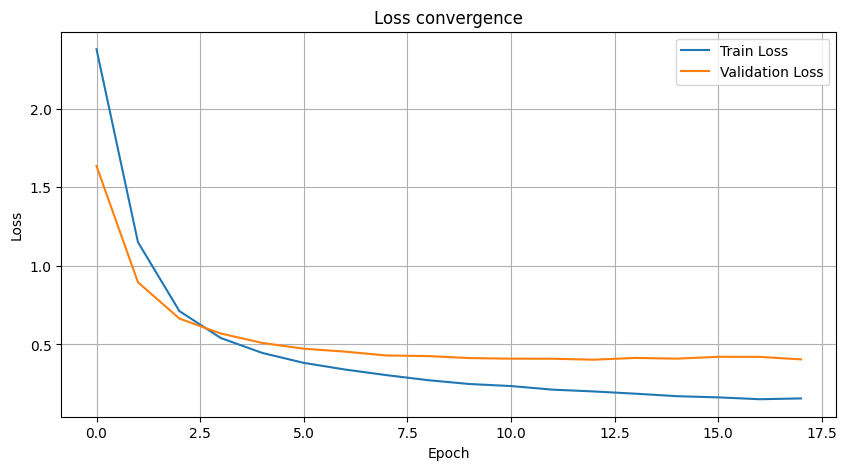

In [ ]:
multihead_attention_encoder = rnn_enc_pos_model

multihead_attention_decoder = RNN_MultiHeadAttention_Decoder(
    vocab_size=len(rus_dict),
    embed_dim=64,
    hidden_size=128,
    n_heads=4,       # 4 как делитель 128
    max_len=rus_max_len
)

multihead_attention_seq2seq_model = MultiHeadAttentionSeq2Seq(multihead_attention_encoder, multihead_attention_decoder)

criterion_multihead_attention_seq2seq = nn.CrossEntropyLoss(reduction="mean", ignore_index=rus_dict[' '])
optimizer_multihead_attention_seq2seq = torch.optim.AdamW(multihead_attention_seq2seq_model.decoder.parameters(), lr=0.001, weight_decay=1e-3)

set_seed(21)

train_losses_multihead_attention_seq2seq, val_losses_multihead_attention_seq2seq = train_seq2seq(
    multihead_attention_seq2seq_model,
    train_translation_loader,
    val_translation_loader,
    criterion_multihead_attention_seq2seq,
    optimizer_multihead_attention_seq2seq,
    num_epochs=20,
    target_lang_vocab_size=len(rus_dict),
    rus_dict=rus_dict
)

### b. Select the name and add the visualization of the attention matrix within the training process. Display the plot every n epochs.

### c. Train the Machine Translation with this block.

In [ ]:
def get_attention_weights_for_name(model, english_name, eng_dict, rus_dict, eng_max_len, rus_max_len, device):
    model.eval()
    model.to(device)

    eng_tokens_str = list(english_name.lower())
    eng_tokens_ids = [eng_dict["<SOS>"]] + [eng_dict[char] for char in eng_tokens_str] + [eng_dict["<EOS>"]]
    eng_padded_ids = eng_tokens_ids + [eng_dict[" "]] * (eng_max_len - len(eng_tokens_ids))
    input_tensor = torch.tensor(eng_padded_ids, dtype=torch.long, device=device).unsqueeze(0) # (1, seq_len)

    embedded_encoder = model.encoder.emb(input_tensor)
    encoder_outputs, encoder_hidden = model.encoder.rnn(embedded_encoder)
    decoder_input = torch.tensor([[rus_dict["<SOS>"]]], dtype=torch.long, device=device)
    decoded_token_ids = []
    all_attention_weights = []

    current_decoder_hidden = encoder_hidden

    for t in range(rus_max_len):
        if isinstance(model.decoder, (RNN_Attention_Decoder, RNN_Attention_Decoder_Positional, RNN_Attention_Decoder_TrainablePositional, RNN_MultiHeadAttention_Decoder)):
            prediction_logits, current_decoder_hidden, attention_weights_per_head = model.decoder(decoder_input, encoder_outputs, current_decoder_hidden)
            next_token_id = prediction_logits.argmax(1).item()

            # attention_weights_per_head: (batch_size, n_heads, 1, encoder_seq_len)
            avg_attention = attention_weights_per_head.mean(dim=1).squeeze().cpu().detach().numpy()
            all_attention_weights.append(avg_attention)
        else:
            return None, None, None, None

        if next_token_id == rus_dict["<EOS>"]:
            break

        decoded_token_ids.append(next_token_id)
        decoder_input = torch.tensor([[next_token_id]], dtype=torch.long, device=device)

    id_to_char_rus = {v: k for k, v in rus_dict.items()}
    translated_rus_tokens_str = [id_to_char_rus[token_id] for token_id in decoded_token_ids if token_id != rus_dict[" "]]

    id_to_char_eng = {v: k for k, v in eng_dict.items()}
    source_tokens_for_plot = [id_to_char_eng[token_id] for token_id in eng_padded_ids]

    target_tokens_for_plot = [id_to_char_rus[rus_dict["<SOS>"]]] + translated_rus_tokens_str + [id_to_char_rus[rus_dict["<EOS>"]]]

    if all_attention_weights:
        expected_enc_len = len(source_tokens_for_plot)
        padded_attention_weights = []
        for att_vec in all_attention_weights:
            if len(att_vec) < expected_enc_len:
                padded_att = np.pad(att_vec, (0, expected_enc_len - len(att_vec)), 'constant', constant_values=0)
                padded_attention_weights.append(padded_att)
            else:
                padded_attention_weights.append(att_vec[:expected_enc_len])

        attention_matrix = np.vstack(padded_attention_weights)
    else:
        attention_matrix = None

    return attention_matrix, source_tokens_for_plot, target_tokens_for_plot, ''.join(translated_rus_tokens_str)

In [ ]:
def train_seq2seq(model, train_loader, valid_loader, criterion, optimizer, num_epochs, scheduler=None, patience=5, target_lang_vocab_size=None, rus_dict=None, english_name_to_visualize=None, plot_attention_every_n_epochs=0):
  train_losses, val_losses = [], []
  device = "cuda" if torch.cuda.is_available() else 'cpu'
  model.to(device)

  best_val_loss = float('inf')
  patience_counter = 0

  for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0
    num_batches_train = 0

    for eng_seq, rus_seq in train_loader:
      eng_seq = eng_seq.to(device)
      rus_seq = rus_seq.to(device)
      optimizer.zero_grad()

      prediction_logits = model(eng_seq, rus_seq)

      output_decoder = prediction_logits.reshape(-1, prediction_logits.size(-1))
      target_decoder = rus_seq[:, 1:].reshape(-1)

      loss = criterion(output_decoder, target_decoder)
      loss.backward()
      optimizer.step()

      total_train_loss += loss.item()
      num_batches_train += 1

    avg_train_loss = total_train_loss / num_batches_train
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0.0
    num_batches_val = 0

    with torch.no_grad():
      for eng_seq, rus_seq in valid_loader:
        eng_seq = eng_seq.to(device)
        rus_seq = rus_seq.to(device)

        prediction_logits = model(eng_seq, rus_seq)

        output_decoder = prediction_logits.reshape(-1, prediction_logits.size(-1))
        target_decoder = rus_seq[:, 1:].reshape(-1)

        loss = criterion(output_decoder, target_decoder)

        total_val_loss += loss.item()
        num_batches_val += 1

      avg_val_loss = total_val_loss / num_batches_val
      val_losses.append(avg_val_loss)

      if scheduler is not None:
        scheduler.step(avg_val_loss)

      print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

      if english_name_to_visualize and plot_attention_every_n_epochs > 0 and (epoch + 1) % plot_attention_every_n_epochs == 0:
          if isinstance(model, (AttentionSeq2Seq, MultiHeadAttentionSeq2Seq)) and isinstance(model.decoder, (RNN_Attention_Decoder, RNN_Attention_Decoder_Positional, RNN_Attention_Decoder_TrainablePositional, RNN_MultiHeadAttention_Decoder)):
              print(f"Visualizing attention for '{english_name_to_visualize}' at epoch {epoch+1}...")
              attention_matrix, source_tokens, target_tokens, translated_name = get_attention_weights_for_name(
                  model, english_name_to_visualize, eng_dict, rus_dict, eng_max_len, rus_max_len, device
              )
              if attention_matrix is not None:
                  print(f"Translated '{english_name_to_visualize}' to '{translated_name}'")
                  plot_attention_matrix(attention_matrix, source_tokens, target_tokens, english_name_to_visualize, epoch + 1)
              else:
                  print(f"Skipping attention visualization for '{english_name_to_visualize}' at epoch {epoch+1}: Decoder does not support attention visualization.")
          else:
              print(f"Skipping attention visualization at epoch {epoch+1}: Model or decoder type not supported for attention visualization.")


    # early stopping
    if avg_val_loss < best_val_loss:
      best_val_loss = avg_val_loss
      patience_counter = 0
      # torch.save(model.state_dict(), 'best_seq2seq_model.pth')
    else:
      patience_counter += 1
      print(f'Validation loss did not improve. Patience: {patience_counter}/{patience}')

    if patience_counter >= patience:
      print(f'Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss for {patience} epochs.')
      break

  plt.figure(figsize=(10,5))
  plt.plot(train_losses, label='Train Loss')
  plt.plot(val_losses, label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Loss convergence')
  plt.legend()
  plt.grid(True)
  plt.show()

  return train_losses, val_losses

In [ ]:
def plot_attention_matrix(attention_matrix, source_tokens, target_tokens, english_name, epoch):
    if attention_matrix is None:
        print(f"Cannot plot attention for '{english_name}' at epoch {epoch}: No attention weights found.")
        return

    if len(target_tokens) != attention_matrix.shape[0]:
        target_tokens = target_tokens[:attention_matrix.shape[0]]

    plt.figure(figsize=(attention_matrix.shape[1] * 0.8, attention_matrix.shape[0] * 0.8))
    sns.heatmap(attention_matrix, cmap='Blues', annot=True, fmt=".2f",
                xticklabels=source_tokens, yticklabels=target_tokens)
    plt.xlabel('English (Encoder) Tokens')
    plt.ylabel('Russian (Decoder) Tokens')
    plt.title(f'Attention Matrix for "{english_name}" at Epoch {epoch}')
    plt.tight_layout()
    plt.show()

Training Multi-Head Attention Decoder with Positional Encoding for Machine Translation...
Epoch 1/20 | Train Loss: 2.3571 | Val Loss: 1.6356
Epoch 2/20 | Train Loss: 1.1585 | Val Loss: 0.8886
Epoch 3/20 | Train Loss: 0.6894 | Val Loss: 0.6635
Epoch 4/20 | Train Loss: 0.5265 | Val Loss: 0.5516
Epoch 5/20 | Train Loss: 0.4425 | Val Loss: 0.5036
Visualizing attention for 'John' at epoch 5...
Translated 'John' to 'джон'


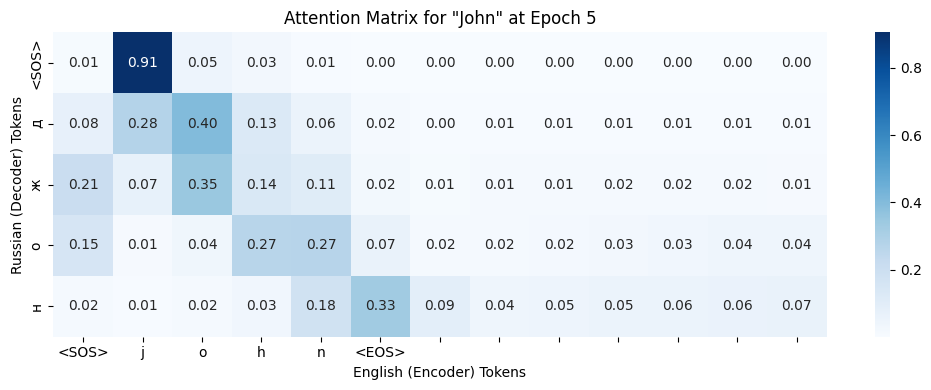

Epoch 6/20 | Train Loss: 0.3839 | Val Loss: 0.4727
Epoch 7/20 | Train Loss: 0.3436 | Val Loss: 0.4477
Epoch 8/20 | Train Loss: 0.3041 | Val Loss: 0.4363
Epoch 9/20 | Train Loss: 0.2762 | Val Loss: 0.4321
Epoch 10/20 | Train Loss: 0.2548 | Val Loss: 0.4164
Visualizing attention for 'John' at epoch 10...
Translated 'John' to 'джонн'


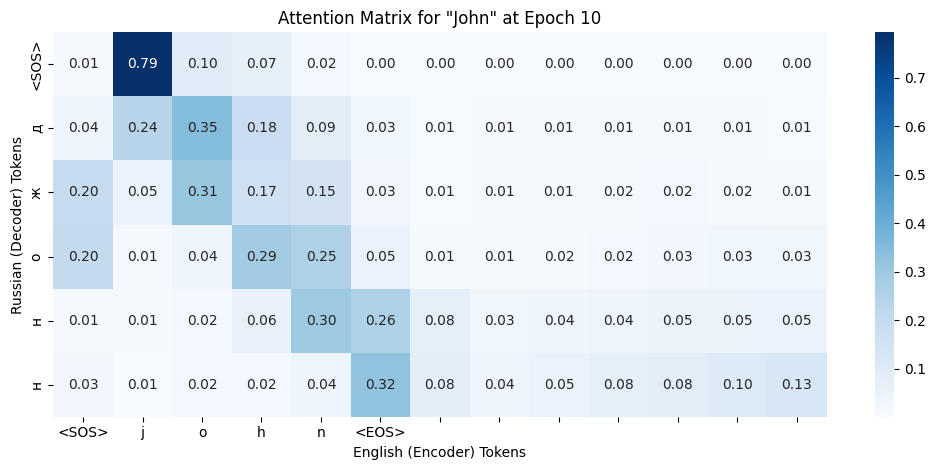

Epoch 11/20 | Train Loss: 0.2404 | Val Loss: 0.4041
Epoch 12/20 | Train Loss: 0.2151 | Val Loss: 0.4027
Epoch 13/20 | Train Loss: 0.2007 | Val Loss: 0.4165
Validation loss did not improve. Patience: 1/5
Epoch 14/20 | Train Loss: 0.1873 | Val Loss: 0.4084
Validation loss did not improve. Patience: 2/5
Epoch 15/20 | Train Loss: 0.1726 | Val Loss: 0.4099
Visualizing attention for 'John' at epoch 15...
Translated 'John' to 'джонн'


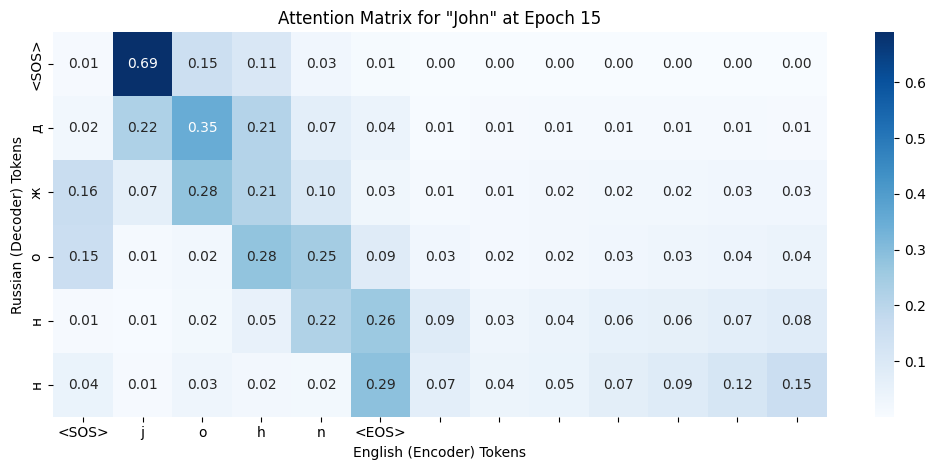

Validation loss did not improve. Patience: 3/5
Epoch 16/20 | Train Loss: 0.1636 | Val Loss: 0.4164
Validation loss did not improve. Patience: 4/5
Epoch 17/20 | Train Loss: 0.1530 | Val Loss: 0.4208
Validation loss did not improve. Patience: 5/5
Early stopping triggered after 17 epochs due to no improvement in validation loss for 5 epochs.


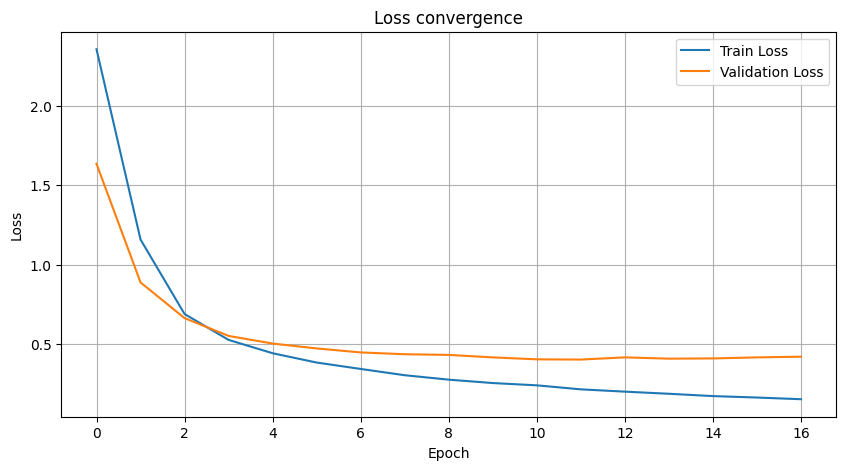

In [ ]:
multihead_attention_encoder = rnn_enc_pos_model
multihead_attention_decoder = RNN_MultiHeadAttention_Decoder(
    vocab_size=len(rus_dict),
    embed_dim=64,
    hidden_size=128,
    n_heads=4,
    max_len=rus_max_len
)

multihead_attention_seq2seq_model = MultiHeadAttentionSeq2Seq(multihead_attention_encoder, multihead_attention_decoder)

criterion_multihead_attention_seq2seq = nn.CrossEntropyLoss(reduction="mean", ignore_index=rus_dict[' '])
optimizer_multihead_attention_seq2seq = torch.optim.AdamW(multihead_attention_seq2seq_model.decoder.parameters(), lr=0.001, weight_decay=1e-3)

set_seed(21)
print("Training Multi-Head Attention Decoder with Positional Encoding for Machine Translation...")
train_losses_multihead_attention_seq2seq, val_losses_multihead_attention_seq2seq = train_seq2seq(
    multihead_attention_seq2seq_model,
    train_translation_loader,
    val_translation_loader,
    criterion_multihead_attention_seq2seq,
    optimizer_multihead_attention_seq2seq,
    num_epochs=20,
    target_lang_vocab_size=len(rus_dict),
    rus_dict=rus_dict,
    english_name_to_visualize='John',
    plot_attention_every_n_epochs=5
)

### d. Evaluate the Multi-Head Attention Decoder with Positional Encoding (repeat 4.e).

In [ ]:
print('English name: John, Русский перевод:', translate_name(multihead_attention_seq2seq_model, 'John', eng_dict, rus_dict))
print('English name: William, Русский перевод:', translate_name(multihead_attention_seq2seq_model, 'William', eng_dict, rus_dict))
print('English name: James, Русский перевод:', translate_name(multihead_attention_seq2seq_model, 'James', eng_dict, rus_dict))
print('English name: Julia, Русский перевод:', translate_name(multihead_attention_seq2seq_model, 'Julia', eng_dict, rus_dict))
print('English name: Moana, Русский перевод:', translate_name(multihead_attention_seq2seq_model, 'Moana', eng_dict, rus_dict))

English name: John, Русский перевод: джонн
English name: William, Русский перевод: вильям
English name: James, Русский перевод: джеймс
English name: Julia, Русский перевод: джулия
English name: Moana, Русский перевод: моана


In [ ]:
print("Perplexity for Multi-Head Attention Decoder with Positional Encoding (Validation Set):")
plp_val_multihead_att = ppl(multihead_attention_seq2seq_model, val_translation_loader)
print("Perplexity for Multi-Head Attention Decoder with Positional Encoding (Test Set):")
plp_test_multihead_att = ppl(multihead_attention_seq2seq_model, test_translation_loader)

Perplexity for Multi-Head Attention Decoder with Positional Encoding (Validation Set):
Perplexity: 1.5232
Perplexity for Multi-Head Attention Decoder with Positional Encoding (Test Set):
Perplexity: 1.4382


In [ ]:
def plot_attention_matrix(attention_matrix, source_tokens, target_tokens, english_name, epoch):
    if attention_matrix is None:
        print(f"Cannot plot attention for '{english_name}' at epoch {epoch}: No attention weights found.")
        return

    if len(target_tokens) != attention_matrix.shape[0]:
        target_tokens = target_tokens[:attention_matrix.shape[0]]

    plt.figure(figsize=(attention_matrix.shape[1] * 0.8, attention_matrix.shape[0] * 0.8))
    sns.heatmap(attention_matrix, cmap='Blues', annot=True, fmt=".2f",
                xticklabels=source_tokens, yticklabels=target_tokens)
    plt.xlabel('English (Encoder) Tokens')
    plt.ylabel('Russian (Decoder) Tokens')
    plt.title(f'Attention Matrix for "{english_name}" at Epoch {epoch}')
    plt.tight_layout()
    plt.show()

Translated 'John' to 'джонн'


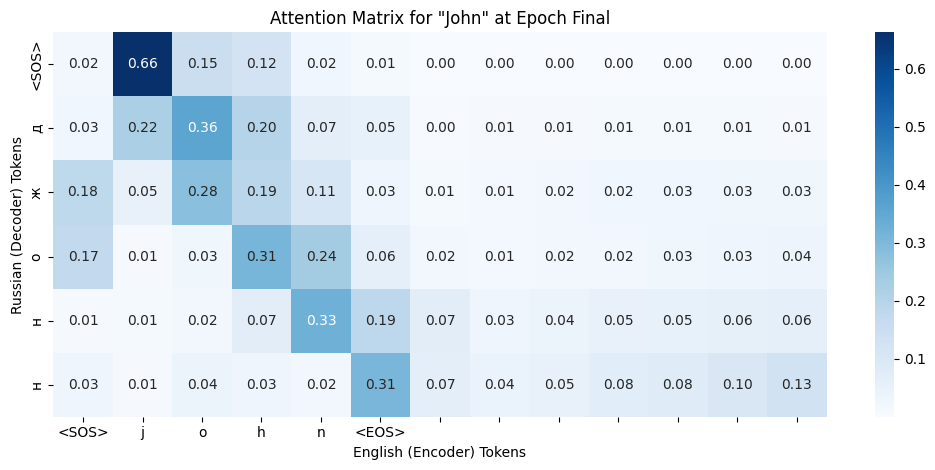

In [ ]:
device = "cuda" if torch.cuda.is_available() else 'cpu'
attention_matrix, source_tokens, target_tokens, translated_name = get_attention_weights_for_name(
    multihead_attention_seq2seq_model, 'john', eng_dict, rus_dict, eng_max_len, rus_max_len, device
)

if attention_matrix is not None:
    print(f"Translated 'John' to '{translated_name}'")
    plot_attention_matrix(attention_matrix, source_tokens, target_tokens, 'John', epoch='Final')
else:
    print("Could not plot attention matrix. Ensure the model and decoder types are correctly handled.")

### e. One of the heads should be almost diagonal with a shift of 1 block. Explain why there is this shift.

- Такой сдвиг у одной из голов означает, что модель использует предыдущий символ исходного имени, чтобы предсказать текущий символ перевода. Это отражение того, что при переводе используется локальный контекст предыдущей позиции, потому что: 1) для предсказания текущего символа i очень полезно знать предыдущий символ источника i-1. и 2) внимание со сдвигом на 1 даёт возможность модели учитывать биграммные правила транслитерации, не усложняя другие головы.

- Save your Multi-Head Attention Machine Translation model in pickle format. Your peer will load it and use it to make predictions again for the test dataset (remember to use the same random state). The predictions should be saved in a file named test_predictions.csv.

In [ ]:
model_save_path = 'multihead_attention_seq2seq_model.pth'
torch.save(multihead_attention_seq2seq_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to multihead_attention_seq2seq_model.pth


In [ ]:
# энкодер (rnn_enc_pos_model)
loaded_multihead_attention_encoder = RNN_Encoder_Positional(
    vocab_size=len(eng_dict),
    embed_dim=64,
    hidden_size=128,
    max_len=eng_max_len
)

# мульти-хэд декодер с вниманием (multihead_attention_decoder)
loaded_multihead_attention_decoder = RNN_MultiHeadAttention_Decoder(
    vocab_size=len(rus_dict),
    embed_dim=64,
    hidden_size=128,
    n_heads=4,
    max_len=rus_max_len
)


loaded_multihead_attention_seq2seq_model = MultiHeadAttentionSeq2Seq(
    loaded_multihead_attention_encoder,
    loaded_multihead_attention_decoder
)

loaded_multihead_attention_seq2seq_model.load_state_dict(torch.load(model_save_path))
loaded_multihead_attention_seq2seq_model.eval()

print("Model loaded successfully and set to evaluation mode.")

Model loaded successfully and set to evaluation mode.


In [ ]:
device = "cuda" if torch.cuda.is_available() else 'cpu'
loaded_multihead_attention_seq2seq_model.to(device)

predictions = []


for _, row in test_data.iterrows():
    english_name = row['English']
    translated_russian_name = translate_name(
        loaded_multihead_attention_seq2seq_model,
        english_name,
        eng_dict,
        rus_dict,
        max_len=rus_max_len
    )
    predictions.append({'English': english_name, 'Predicted_Russian': translated_russian_name})

predictions_df = pd.DataFrame(predictions)
predictions_output_path = 'test_predictions.csv'
predictions_df.to_csv(predictions_output_path, index=False)

print(f"Predictions saved to {predictions_output_path}")
display(predictions_df.head())

Predictions saved to test_predictions.csv


,English,Predicted_Russian
0,Avery,авери
1,Aiyana,айяна
2,Sina,сина
3,Eryn,эрин
4,Samir,самир


# 8*. Bonus Part

## 1. Repetition of the Transformer Architecture for the name translation task.

- Я руководствовалась статьей (https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf), только без layer-normalization

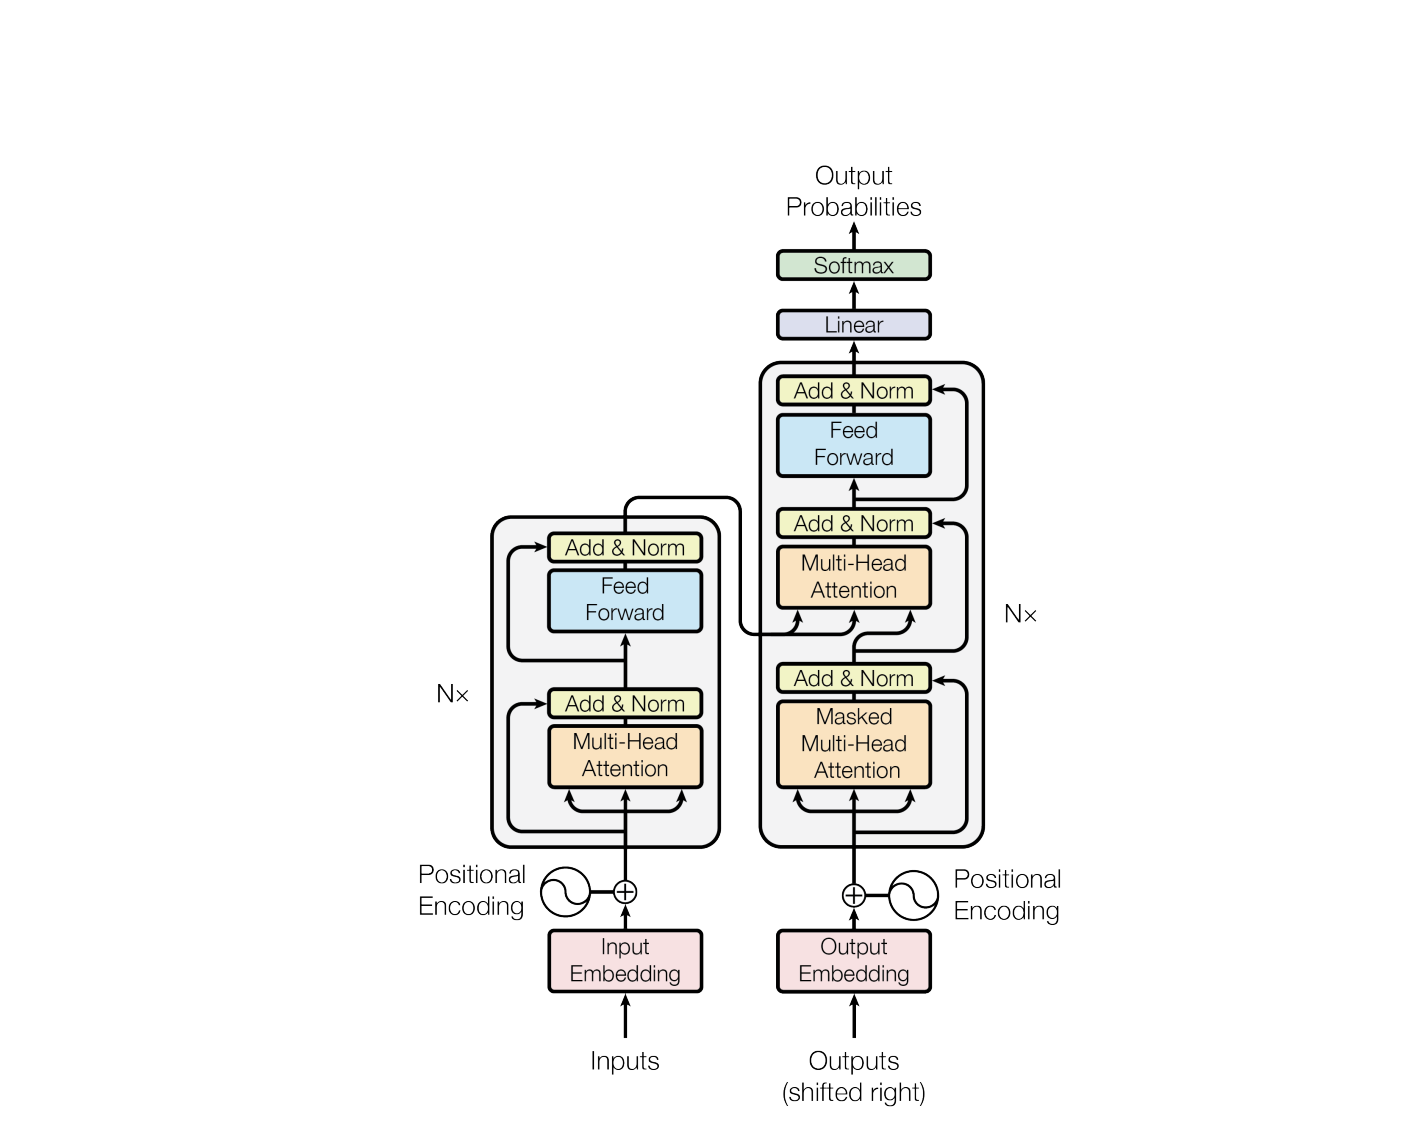

In [ ]:
d_model = 64  # размерность эмебддингов
d_ff = 128    # так называемый feed-forward слой (по сути полносвязный)
num_heads = 4
num_encoder_layers = 2
num_decoder_layers = 2
dropout_rate = 0.1

In [ ]:
# слой, который применяется после внимания для внесения нелинейности
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.relu(self.w_1(x))))

In [ ]:
# создаем маски - для игнорирования паддинга и запрета подглядывания на след токены во время обучения
def subsequent_mask(size):
    # не только лишь все могут смотреть в будущее (модель не может)
    attn_shape = (1, size, size)
    # позиция i не видит позицию >
    subsequent_mask = torch.triu(torch.ones(attn_shape), diagonal=1).type(torch.bool) == 0
    return subsequent_mask

def make_std_mask(tgt, pad):
    tgt_mask = (tgt != pad).unsqueeze(-2)
    tgt_mask = tgt_mask & subsequent_mask(tgt.size(-1)).type_as(tgt_mask.data)
    return tgt_mask

def create_masks(src_seq, tgt_seq, src_pad_idx, tgt_pad_idx, device):
    src_mask = (src_seq != src_pad_idx).unsqueeze(1).unsqueeze(2).to(device)
    tgt_mask = make_std_mask(tgt_seq, tgt_pad_idx).unsqueeze(1).to(device)
    return src_mask, tgt_mask

In [ ]:
class TransformerMultiHeadAttention(MultiHeadAttention):
    def __init__(self, hidden_size, n_heads=4, dropout=0.1):
        super().__init__(hidden_size, n_heads)
        self.dropout_layer = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        x, attention_weights = super().forward(query, key, value, mask)
        return self.dropout_layer(x), attention_weights

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, size, self_attn, feed_forward, dropout):
        super().__init__()
        self.self_attn = self_attn
        self.feed_forward = feed_forward
        self.dropout = nn.Dropout(dropout)
        self.size = size

    def forward(self, x, mask):
        # self-attention
        attn_output, _ = self.self_attn(x, x, x, mask)
        x = x + self.dropout(attn_output)

        # fc layer
        x = x + self.dropout(self.feed_forward(x))
        return x

class TransformerEncoder(nn.Module):
    def __init__(self, layer, N, vocab_size, embed_dim, hidden_size, dropout, max_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoder = PositionalEncoding(embed_dim, max_len)
        self.layers = nn.ModuleList([layer for _ in range(N)])
        self.output_linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.embedding(x)
        x = self.pos_encoder(x)
        x = self.dropout(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, size, self_attn, src_attn, feed_forward, dropout):
        super(DecoderLayer, self).__init__()
        self.size = size
        self.self_attn = self_attn # self - всё из x.
        self.src_attn = src_attn # cross - x из декодера (Q), memory из энкодера (K, V)
        self.feed_forward = feed_forward
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, memory, src_mask, tgt_mask):

        # self-attention
        attn_output, _ = self.self_attn(x, x, x, tgt_mask)
        x = x + self.dropout(attn_output)

        # encoder-decoder Attention
        src_attn_output, _ = self.src_attn(x, memory, memory, src_mask)
        x = x + self.dropout(src_attn_output)
        x = x + self.dropout(self.feed_forward(x))
        return x

class TransformerDecoder(nn.Module):
    def __init__(self, layer, N, vocab_size, embed_dim, hidden_size, dropout, max_len):
        super(TransformerDecoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoder = PositionalEncoding(embed_dim, max_len)
        self.layers = nn.ModuleList([layer for _ in range(N)])
        self.output_linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.vocab_size = vocab_size

    def forward(self, x, memory, src_mask, tgt_mask):
        x = self.embedding(x)
        x = self.pos_encoder(x)
        x = self.dropout(x)
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.output_linear(x)

In [ ]:
class Transformer(nn.Module):
    def __init__(self, encoder, decoder, src_embed_dim, tgt_embed_dim, src_vocab, tgt_vocab):
        super(Transformer, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed_dim = src_embed_dim
        self.tgt_embed_dim = tgt_embed_dim
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab


    def forward(self, src, tgt, src_mask, tgt_mask):
        # src: (batch_size, src_seq_len)
        # tgt: (batch_size, tgt_seq_len)
        # src_mask: (batch_size, 1, 1, src_seq_len)
        # tgt_mask: (batch_size, 1, tgt_seq_len, tgt_seq_len)

        memory = self.encode(src, src_mask)
        output = self.decode(memory, src_mask, tgt, tgt_mask)
        return output

    def encode(self, src, src_mask):
        return self.encoder(src, src_mask)

    def decode(self, memory, src_mask, tgt, tgt_mask):
        return self.decoder(tgt, memory, src_mask, tgt_mask)

#### help functions to transformers

In [ ]:
def train_transformer(model, train_loader, valid_loader, criterion, optimizer, num_epochs, src_pad_idx, tgt_pad_idx, scheduler=None, patience=5):
  train_losses, val_losses = [], []
  device = "cuda" if torch.cuda.is_available() else 'cpu'
  model.to(device)

  best_val_loss = float('inf')
  patience_counter = 0

  for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0
    num_batches_train = 0

    for eng_seq, rus_seq in train_loader:
      eng_seq = eng_seq.to(device) # (batch_size, eng_seq_len)
      rus_seq = rus_seq.to(device) # (batch_size, rus_seq_len)
      optimizer.zero_grad()

      src_mask, tgt_mask = create_masks(eng_seq, rus_seq[:, :-1], src_pad_idx, tgt_pad_idx, device)
      prediction_logits = model(eng_seq, rus_seq[:, :-1], src_mask, tgt_mask) # (batch_size, tgt_seq_len-1, vocab_size)

      output_decoder = prediction_logits.reshape(-1, prediction_logits.size(-1)) # ((batch_size * (tgt_seq_len-1)), vocab_size)
      target_decoder = rus_seq[:, 1:].reshape(-1) # (batch_size * (tgt_seq_len-1))

      loss = criterion(output_decoder, target_decoder)
      loss.backward()
      optimizer.step()

      total_train_loss += loss.item()
      num_batches_train += 1

    avg_train_loss = total_train_loss / num_batches_train
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0.0
    num_batches_val = 0

    with torch.no_grad():
      for eng_seq, rus_seq in valid_loader:
        eng_seq = eng_seq.to(device)
        rus_seq = rus_seq.to(device)

        src_mask, tgt_mask = create_masks(eng_seq, rus_seq[:, :-1], src_pad_idx, tgt_pad_idx, device)

        prediction_logits = model(eng_seq, rus_seq[:, :-1], src_mask, tgt_mask)

        output_decoder = prediction_logits.reshape(-1, prediction_logits.size(-1))
        target_decoder = rus_seq[:, 1:].reshape(-1)

        loss = criterion(output_decoder, target_decoder)

        total_val_loss += loss.item()
        num_batches_val += 1

      avg_val_loss = total_val_loss / num_batches_val
      val_losses.append(avg_val_loss)

      if scheduler is not None:
        scheduler.step(avg_val_loss)

      print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

    # early stopping
    if avg_val_loss < best_val_loss:
      best_val_loss = avg_val_loss
      patience_counter = 0
    else:
      patience_counter += 1
      print(f'Validation loss did not improve. Patience: {patience_counter}/{patience}')

    if patience_counter >= patience:
      print(f'Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss for {patience} epochs.')
      break

  plt.figure(figsize=(10,5))
  plt.plot(train_losses, label='Train Loss')
  plt.plot(val_losses, label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Loss convergence')
  plt.legend()
  plt.grid(True)
  plt.show()

  return train_losses, val_losses

In [ ]:
def translate_name_transformers(model, english_name, eng_dict, rus_dict, max_len=14):
    model.eval()
    device = "cuda" if torch.cuda.is_available() else 'cpu'
    model.to(device)

    eng_tokens = [eng_dict["<SOS>"]] + [eng_dict[char] for char in english_name.lower()] + [eng_dict["<EOS>"]]
    eng_padded = eng_tokens + [eng_dict[" "]] * (eng_max_len - len(eng_tokens))
    input_tensor = torch.tensor(eng_padded, dtype=torch.long, device=device).unsqueeze(0) # (1, S)

    src_mask = (input_tensor != eng_dict[' ']).unsqueeze(1).unsqueeze(2).to(device)
    memory = model.encode(input_tensor, src_mask)

    decoder_input = torch.tensor([[rus_dict["<SOS>"]]], dtype=torch.long, device=device)
    decoded_tokens = []

    for _ in range(max_len):
        tgt_mask = make_std_mask(decoder_input, rus_dict[' ']).unsqueeze(1).to(device)

        prediction_logits = model.decode(memory, src_mask, decoder_input, tgt_mask)
        # (1, current_tgt_seq_len, vocab_size)
        next_token_id = prediction_logits[:, -1, :].argmax(1).item()

        if next_token_id == rus_dict["<EOS>"]:
            break

        decoded_tokens.append(next_token_id)
        decoder_input = torch.cat([decoder_input, torch.tensor([[next_token_id]], dtype=torch.long, device=device)], dim=1)

    # ids to chrs
    id_to_char = {v: k for k, v in rus_dict.items()}
    translated_rus_tokens_str = [id_to_char[token_id] for token_id in decoded_tokens if token_id != rus_dict[" "]]

    return ''.join(translated_rus_tokens_str)

In [ ]:
def ppl_transformer(model, loader, src_pad_idx, tgt_pad_idx):
  device = next(model.parameters()).device
  criterion = nn.CrossEntropyLoss(reduction='mean', ignore_index=rus_dict[' '])

  model.eval()
  total_loss = 0
  num_batches = 0
  with torch.no_grad():
      for eng_seq, rus_seq in loader:
          eng_seq = eng_seq.to(device)
          rus_seq = rus_seq.to(device)

          src_mask, tgt_mask = create_masks(eng_seq, rus_seq[:, :-1], src_pad_idx, tgt_pad_idx, device)

          logits = model(eng_seq, rus_seq[:, :-1], src_mask, tgt_mask)
          loss = criterion(logits.reshape(-1, logits.size(-1)), rus_seq[:, 1:].reshape(-1))
          total_loss += loss.item()
          num_batches +=1

  avg_loss = total_loss / num_batches
  ppl_score = math.exp(avg_loss)
  print(f"Perplexity: {ppl_score:.4f}")
  return ppl_score

#### обучение и оценка трансформера

Training Transformer Model...
Epoch 1/30 | Train Loss: 2.4711 | Val Loss: 1.6763
Epoch 2/30 | Train Loss: 1.5135 | Val Loss: 1.0034
Epoch 3/30 | Train Loss: 1.1251 | Val Loss: 0.7648
Epoch 4/30 | Train Loss: 0.9386 | Val Loss: 0.6548
Epoch 5/30 | Train Loss: 0.8484 | Val Loss: 0.6002
Epoch 6/30 | Train Loss: 0.7690 | Val Loss: 0.5531
Epoch 7/30 | Train Loss: 0.7186 | Val Loss: 0.5225
Epoch 8/30 | Train Loss: 0.6798 | Val Loss: 0.4903
Epoch 9/30 | Train Loss: 0.6495 | Val Loss: 0.4794
Epoch 10/30 | Train Loss: 0.6183 | Val Loss: 0.4632
Epoch 11/30 | Train Loss: 0.5898 | Val Loss: 0.4468
Epoch 12/30 | Train Loss: 0.5680 | Val Loss: 0.4363
Epoch 13/30 | Train Loss: 0.5506 | Val Loss: 0.4317
Epoch 14/30 | Train Loss: 0.5367 | Val Loss: 0.4146
Epoch 15/30 | Train Loss: 0.5123 | Val Loss: 0.4054
Epoch 16/30 | Train Loss: 0.5047 | Val Loss: 0.4086
Validation loss did not improve. Patience: 1/5
Epoch 17/30 | Train Loss: 0.4954 | Val Loss: 0.4005
Epoch 18/30 | Train Loss: 0.4731 | Val Loss: 0.3

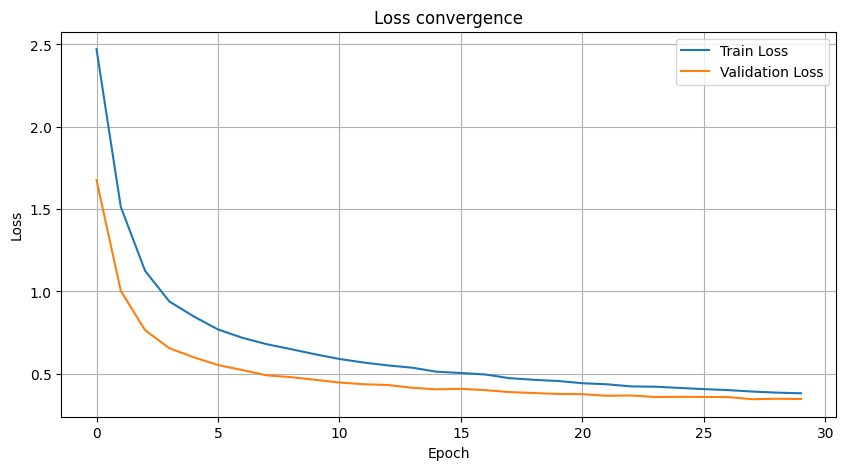

In [ ]:
attn_encoder = TransformerMultiHeadAttention(d_model, num_heads, dropout_rate)
attn_decoder_self = TransformerMultiHeadAttention(d_model, num_heads, dropout_rate)
attn_decoder_src = TransformerMultiHeadAttention(d_model, num_heads, dropout_rate)

ff = PositionwiseFeedForward(d_model, d_ff, dropout_rate)
encoder_layer = EncoderLayer(d_model, attn_encoder, ff, dropout_rate)
decoder_layer = DecoderLayer(d_model, attn_decoder_self, attn_decoder_src, ff, dropout_rate)


transformer_encoder = TransformerEncoder(
    layer=encoder_layer,
    N=num_encoder_layers,
    vocab_size=len(eng_dict),
    embed_dim=d_model,
    hidden_size=d_model,
    dropout=dropout_rate,
    max_len=eng_max_len
)

transformer_decoder = TransformerDecoder(
    layer=decoder_layer,
    N=num_decoder_layers,
    vocab_size=len(rus_dict),
    embed_dim=d_model,
    hidden_size=d_model,
    dropout=dropout_rate,
    max_len=rus_max_len
)


transformer_model = Transformer(
    encoder=transformer_encoder,
    decoder=transformer_decoder,
    src_embed_dim=d_model,
    tgt_embed_dim=d_model,
    src_vocab=len(eng_dict),
    tgt_vocab=len(rus_dict)
)


criterion_transformer = nn.CrossEntropyLoss(reduction="mean", ignore_index=rus_dict[' '])
optimizer_transformer = torch.optim.AdamW(transformer_model.parameters(), lr=0.0005, weight_decay=1e-4)


eng_pad_idx = eng_dict[' ']
rus_pad_idx = rus_dict[' ']

set_seed(21)

print("Training Transformer Model...")
train_losses_transformer, val_losses_transformer = train_transformer(
    transformer_model,
    train_translation_loader,
    val_translation_loader,
    criterion_transformer,
    optimizer_transformer,
    num_epochs=30,
    src_pad_idx=eng_pad_idx,
    tgt_pad_idx=rus_pad_idx
)

In [ ]:
print("Perplexity for Multi-Head Attention Decoder with Positional Encoding (Validation Set):")
plp_val_multihead_att = ppl_transformer(transformer_model, val_translation_loader, eng_pad_idx, rus_pad_idx)
print("Perplexity for Multi-Head Attention Decoder with Positional Encoding (Test Set):")
plp_test_multihead_att = ppl_transformer(transformer_model, test_translation_loader, eng_pad_idx, rus_pad_idx)

Perplexity for Multi-Head Attention Decoder with Positional Encoding (Validation Set):
Perplexity: 1.4143
Perplexity for Multi-Head Attention Decoder with Positional Encoding (Test Set):
Perplexity: 1.3407


In [ ]:
print('English name: John, Русский перевод:', translate_name_transformers(transformer_model, 'John', eng_dict, rus_dict))
print('English name: William, Русский перевод:', translate_name_transformers(transformer_model, 'William', eng_dict, rus_dict))
print('English name: James, Русский перевод:', translate_name_transformers(transformer_model, 'James', eng_dict, rus_dict))
print('English name: Julia, Русский перевод:', translate_name_transformers(transformer_model, 'Julia', eng_dict, rus_dict))
print('English name: Moana, Русский перевод:', translate_name_transformers(transformer_model, 'Moana', eng_dict, rus_dict))

English name: John, Русский перевод: джон
English name: William, Русский перевод: уиллим
English name: James, Русский перевод: джеймс
English name: Julia, Русский перевод: джулия
English name: Moana, Русский перевод: мона


## 2. Transform names and translations into n-gram vectors. Implement and measure the BLEU metric.

- BLEU (Bilingual Evaluation Understudy) - автоматическая метрика для оценки качества машинного перевода, измеряющая лексическую близость сгенерированного текста к эталонному (человеческому) на основе n-грамм. Она варьируется от 0 до 1, чем ближе к 1, тем лучше.

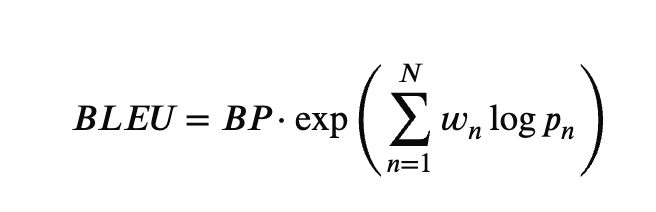

In [ ]:
def calculate_ngram_counts(tokens, n):
    ngrams = Counter()
    for i in range(len(tokens) - n + 1):
        ngram = tuple(tokens[i:i+n])
        ngrams[ngram] += 1
    return ngrams

def brevity_penalty(candidate_len, reference_len):
    if candidate_len > reference_len:
        return 1.0
    if candidate_len == 0:
        return 0.0
    return math.exp(1 - reference_len / candidate_len)

def bleu_score(candidate_tokens, reference_tokens_list, max_n=2):
    candidate_len = len(candidate_tokens)
    closest_ref_len = min(len(ref) for ref in reference_tokens_list)

    precisions = []
    for n in range(1, max_n + 1):
        candidate_ngrams = calculate_ngram_counts(candidate_tokens, n)
        reference_ngrams_union = Counter()
        for ref_tokens in reference_tokens_list:
            reference_ngrams_union.update(calculate_ngram_counts(ref_tokens, n))

        clipped_count = 0
        total_count = sum(candidate_ngrams.values())

        for ngram, count in candidate_ngrams.items():
            clipped_count += min(count, reference_ngrams_union[ngram])

        if total_count == 0:
            precisions.append(0.0)
        else:
            precisions.append(clipped_count / total_count)


    for i in range(len(precisions)):
        if precisions[i] == 0.0:
            precisions[i] = 1e-9

    geometric_mean = math.exp(sum(math.log(p) for p in precisions) / max_n)
    bp = brevity_penalty(candidate_len, closest_ref_len)
    bleu = bp * geometric_mean
    return bleu

In [ ]:
test_data

,English,eng_name_to_id,rus_name_to_id
642,Avery,"[27, 1, 22, 5, 18, 25, 28, 0, 0, 0, 0, 0, 0]","[34, 31, 3, 6, 18, 10, 35, 0, 0, 0, 0, 0, 0, 0]"
6527,Aiyana,"[27, 1, 9, 25, 1, 14, 1, 28, 0, 0, 0, 0, 0]","[34, 1, 11, 33, 15, 1, 35, 0, 0, 0, 0, 0, 0, 0]"
3762,Sina,"[27, 19, 9, 14, 1, 28, 0, 0, 0, 0, 0, 0, 0]","[34, 19, 10, 15, 1, 35, 0, 0, 0, 0, 0, 0, 0, 0]"
6286,Eryn,"[27, 5, 18, 25, 14, 28, 0, 0, 0, 0, 0, 0, 0]","[34, 31, 18, 10, 15, 35, 0, 0, 0, 0, 0, 0, 0, 0]"
2814,Samir,"[27, 19, 1, 13, 9, 18, 28, 0, 0, 0, 0, 0, 0]","[34, 19, 1, 14, 10, 18, 35, 0, 0, 0, 0, 0, 0, 0]"
...,...,...,...
4751,Eathel,"[27, 5, 1, 20, 8, 5, 12, 28, 0, 0, 0, 0, 0]","[34, 10, 31, 20, 6, 13, 35, 0, 0, 0, 0, 0, 0, 0]"
3562,Lilla,"[27, 12, 9, 12, 12, 1, 28, 0, 0, 0, 0, 0, 0]","[34, 13, 10, 13, 13, 1, 35, 0, 0, 0, 0, 0, 0, 0]"
6530,Nyasia,"[27, 14, 25, 1, 19, 9, 1, 28, 0, 0, 0, 0, 0]","[34, 15, 10, 1, 19, 10, 33, 35, 0, 0, 0, 0, 0, 0]"
3257,Keshaun,"[27, 11, 5, 19, 8, 1, 21, 14, 28, 0, 0, 0, 0]","[34, 12, 6, 26, 16, 15, 35, 0, 0, 0, 0, 0, 0, 0]"


In [ ]:
train_data, testval_data = train_test_split(name_data[['English','Russian','eng_name_to_id','rus_name_to_id']], test_size = 0.2, random_state=21)
valid_data, test_data = train_test_split(testval_data, test_size = 0.5, random_state=21)

In [ ]:
predicted_russian_names = predictions_df['Predicted_Russian'].tolist()
reference_russian_names = test_data['Russian'].tolist()

predicted_tokens = [[char for char in name] for name in predicted_russian_names]
reference_tokens = [[[char for char in name]] for name in reference_russian_names]


bleu_scores = []
for i in range(len(predicted_tokens)):
    score = bleu_score(predicted_tokens[i], reference_tokens[i])
    bleu_scores.append(score)


predictions_df['BLEU_Score'] = bleu_scores
display(predictions_df.head())
average_bleu_score = sum(bleu_scores) / len(bleu_scores)
print(f"\nAverage BLEU Score on Test Set: {average_bleu_score:.4f}")

,English,Predicted_Russian,BLEU_Score
0,Avery,авери,0.774597
1,Aiyana,айяна,0.774597
2,Sina,сина,0.707107
3,Eryn,эрин,0.707107
4,Samir,самир,0.774597



Average BLEU Score on Test Set: 0.6414


- Получили среднее значени 0.6, что указывает на хорошее качество перевода (с учетом того, что метрика сильно штрафует короткие последовательности за ошибки)